***N.B. this notebook has been tested in Google Colab***

# Music Genre Classification

In this project, you will build a machine learning algorithm to classify music genres using audio features. Starting with the provided dataset, your task is to develop a model that effectively solves this multiclass classification problem. Use the baseline notebook as a starting point and improve upon it.

***Overall Goal: to design a complete pipeline that improves accuracy from the current 37% to at least 70%, ideally approaching 80%***


## Introduction

In this project, you will work with a dataset of music samples from various genres. The dataset has been purposely left a bit messy, with some entries missing labels and others containing empty audio files. To start with, your task is to clean and explore the dataset, turning it into a well-organized resource for analysis.

This notebook includes a basic, "weak" baseline to get you started. It serves as a simple starting point, but it is neither thorough nor accurate. You are expected to build upon it, applying your own strategies to improve the data science pipeline (including data cleaning, curation, feature engineering, etc) before moving into model building, parameters tuning, and model evaluation.

The formal details of the assignment are provided at the end of the notebook. To start with, focus on understanding the dataset and planning your strategies to tackle its challenges.

**We expect you to submit a modified version of this notebook with your improvements. Please download a copy of this assignment in your private Python programming environment, before making any changes.**

## Baseline

Let's install all required dependencies:

- **datasets**: Access to large-scale datasets.
- **librosa**: Tools for audio analysis.
- **pandas** & **numpy**: Tabular data manipulation and numerical operations.
- **scikit-learn**: Machine learning algorithms and tools.
- **tqdm**: Progress bar.

You might be familiar with most of these already.

In [1]:
%%capture
%pip install datasets==3.5.0 librosa pandas numpy scikit-learn tqdm

And import the necessary modules
keras - https://keras.io/
librosa - https://librosa.github.io/librosa/
matplotlab - https://matplotlib.org/
pandas - https://pandas.pydata.org/
tensorflow (Requires Python 3.6) - https://www.tensorflow.org/

keras        – High-level API to build and train neural networks.
librosa      – Audio signal processing and feature extraction for music.
matplotlib   – Visualization of data, training curves, and results.
pandas       – Data handling and organization of features and labels.
tensorflow   – Backend framework for numerical computation and deep learning.
numpy        – Numerical computing with arrays and matrices, used for audio data and feature manipulation.

In [2]:
# ============================================================
# IMPORTS COMPLETI E PULITI
# ============================================================

# --- Standard library ---
import csv
import datetime
import hashlib
import math
import random
import statistics
from random import randint, seed
from itertools import combinations

# --- Core scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Audio processing ---
import librosa
import librosa.display
from scipy import signal

# --- Visualization extras ---
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.collections import PolyCollection

# --- HuggingFace datasets ---
from datasets import load_dataset, Dataset

# --- Jupyter display ---
from IPython.display import Audio, display

# --- Progress bar ---
from tqdm.auto import tqdm

# --- Model persistence ---
import joblib

# ============================================================
# SCIKIT-LEARN
# ============================================================

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import DBSCAN
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# Pipelines
from sklearn.pipeline import Pipeline

# ============================================================
# IMBALANCED-LEARN
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ============================================================
# KERAS
# ============================================================
import keras
from keras import models, layers

c:\Users\teosf\anaconda3\envs\mio_ambiente\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA EXPLORATION AND CURATION

### Dataset Description

The dataset consists of music samples from various genres, including:

- **Genres**: `Blues`, `Classical`, `Country`, `Disco`, `HipHop`, `Jazz`, `Metal`, `Pop`, `Reggae`, and `Rock`.

The dataset is a bit messy and includes some **unlabeled data** and **empty audio files**. We have provided basic preprocessing, but more in-depth data cleaning, feature extraction, and preparation will be a part of your assignment.

Let's download the audio dataset using the Hugging Face datasets library.

In [3]:
dataset = load_dataset("unibz-ds-course/audio_assignment", split="train")

In [4]:
dataset

Dataset({
    features: ['file', 'audio', 'genre'],
    num_rows: 1230
})

In [5]:
print(f"Num of samples in the dataset: {len(dataset)}")

Num of samples in the dataset: 1230


Let's take a glance at a sample from the dataset

In [6]:
entry = dataset[10]

audio_array = entry['audio']['array']
sampling_rate = entry['audio']['sampling_rate']

print(f"Element: {entry}")
print(f"File Path: {entry['file']}")
print(f"Number of Samples: {len(audio_array)}")
print(f"Sampling Rate: {sampling_rate} Hz")

audio_length_seconds = len(audio_array) / sampling_rate
print(f"Audio Length: {audio_length_seconds:.2f} seconds")

genre_id = entry['genre']
genre_label = dataset.features['genre'].int2str(genre_id)
print(f"Genre (ID): {genre_id}")
print(f"Genre (Label): {genre_label}")

display(Audio(audio_array, rate=sampling_rate))

Element: {'file': 'audio_data/country/country.00247.wav', 'audio': {'path': 'country.00247.wav', 'array': array([-0.01055908, -0.01712036, -0.02111816, ...,  0.03747559,
        0.01239014, -0.03366089], shape=(661794,)), 'sampling_rate': 22050}, 'genre': 2}
File Path: audio_data/country/country.00247.wav
Number of Samples: 661794
Sampling Rate: 22050 Hz
Audio Length: 30.01 seconds
Genre (ID): 2
Genre (Label): country


**Draw a plot with distribution of the classes (5 points)**

Create a visualization (e.g., bar chart or histogram) that shows how many samples belong to each class.
This helps identify whether the dataset is balanced or if some classes are underrepresented.

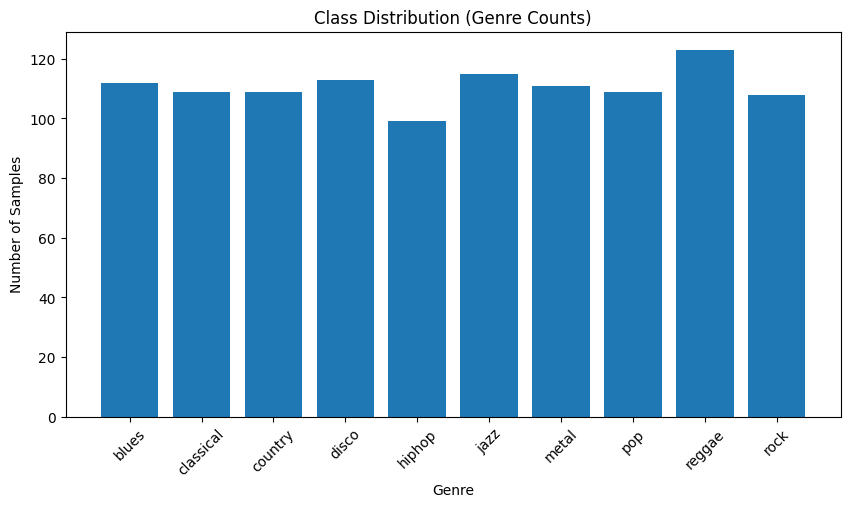

In [7]:
df = dataset.to_pandas()

# Remove missing labels
df = df.dropna(subset=['genre'])

# Convert to int
df['genre'] = df['genre'].astype(int)

# Count
counts = df['genre'].value_counts().sort_index()

# Map to names
genre_names = [dataset.features['genre'].int2str(i) for i in counts.index]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(genre_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (Genre Counts)")
plt.xlabel("Genre")
plt.ylabel("Number of Samples")
plt.show()

This graph helped visualize whether there are class imbalances. At this point there are no severe imbalances.

**Draw distribution of lengths of audios (5 points)**

Plot the distribution of audio lengths in the dataset to analyze how durations vary across samples.

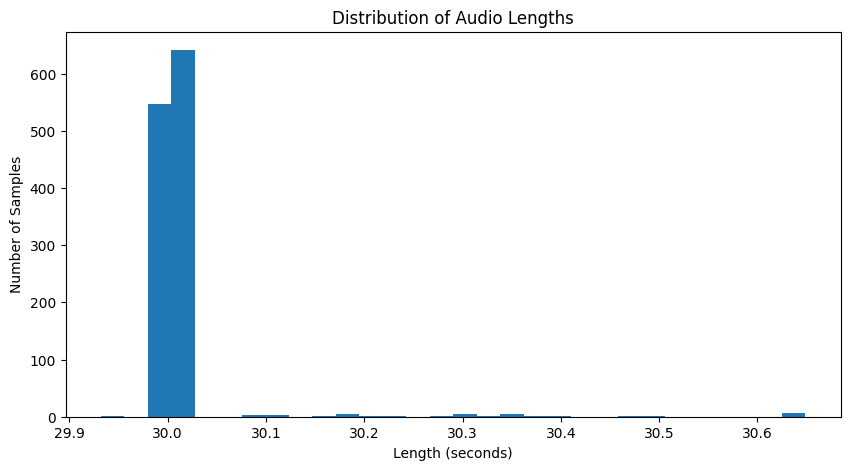

In [8]:
# compute length in seconds for each audio sample
lengths = [
    entry['audio']['array'].shape[0] / entry['audio']['sampling_rate']
    for entry in dataset
    if entry['audio'] is not None
]

# plot histogram
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30)
plt.title("Distribution of Audio Lengths")
plt.xlabel("Length (seconds)")
plt.ylabel("Number of Samples")
plt.show()

Also in this case there is no severe class imbalance

### **Delete empty samples (5 points)**

Implement the function to remove empty samples (audios with silence only)

In [9]:
def filter_empty_samples(entry):
    audio = entry["audio"]
    
    if audio is None:
        return False
    
    arr = audio["array"]
    if arr is None or len(arr) == 0:
        return False
    
    # Check silence (all zeros)
    if (arr == 0).all():
        return False
    
    return True


filtered_dataset = dataset.filter(filter_empty_samples)

print("Original:", len(dataset))
print("Filtered:", len(filtered_dataset))


Original: 1230
Filtered: 970


In [10]:
filtered_dataset = dataset.filter(filter_empty_samples)

## Remove noise only audios

In [11]:
def is_music_like(audio, rms_thresh=0.02, flatness_thresh=0.2):
    arr = audio["array"]

    rms = librosa.feature.rms(y=arr).mean()
    flatness = librosa.feature.spectral_flatness(y=arr).mean()

    return (rms > rms_thresh) and (flatness < flatness_thresh)

def filter_music_samples(entry):
    audio = entry["audio"]
    if audio is None:
        return False

    arr = audio["array"]
    if arr is None or len(arr) == 0:
        return False

    return is_music_like(audio)

# **apply filter on the already deduplicated dataset**
filtered_dataset = filtered_dataset.filter(filter_music_samples)

print("Original:", len(dataset))
print("Filtered:", len(filtered_dataset))


Original: 1230
Filtered: 945


### **Delete unlabeled samples (5 points)**

Implement the function to remove unlabeled samples.

In [12]:


def filter_valid_samples(entry):
    # remove unlabeled
    genre = entry["genre"]
    if genre is None or (isinstance(genre, float) and math.isnan(genre)):
        return False

    # remove empty audio
    audio = entry["audio"]
    if audio is None:
        return False
    arr = audio["array"]
    if arr is None or len(arr) == 0:
        return False
    if np.all(arr == 0):
        return False

    return True

filtered_dataset = dataset.filter(filter_valid_samples)

print("Original:", len(dataset))
print("Filtered:", len(filtered_dataset))



Original: 1230
Filtered: 848


### Delete duplicated audios

Duplicate removal is carried out in two stages, each addressing a different source of redundancy in the dataset. The first stage operates directly on the raw audio data. For each audio file, a compact signature is computed using summary statistics of MFCCs (mean and standard deviation) and the signal duration. These signatures are then clustered with DBSCAN using a very small distance threshold, so that only virtually identical recordings are grouped together. From each group, a single representative sample is retained. This step removes duplicated or re-encoded versions of the same audio track before feature extraction, preventing information leakage between training and test sets.

The second stage is applied after feature extraction and feature merging. Here, duplicates are identified by checking for identical rows in the final feature matrix. Samples with exactly the same feature vectors are grouped together. If all samples in a group share the same genre label, only the first occurrence is kept; if conflicting genre labels are found, all samples in that group are removed to avoid introducing label noise. This stricter, feature-level deduplication acts as a final consistency check, ensuring that no duplicate observations—either accidental or caused by preprocessing artifacts—remain in the dataset used for modeling. Together, these two steps improve data integrity, reduce overfitting risk, and lead to a more reliable evaluation of model performance.


**FIRST STAGE DUPLICATE REMOVAL**

In [13]:


def compute_signature(audio):
    arr = audio["array"]
    sr = audio["sampling_rate"]

    mfcc = librosa.feature.mfcc(y=arr, sr=sr, n_mfcc=20)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)
    duration = len(arr) / sr

    return np.concatenate([mfcc_mean, mfcc_std, [duration]])


rows = []
for i in range(len(filtered_dataset)):
    e = filtered_dataset[i]
    sig = compute_signature(e["audio"])
    rows.append({
        "idx": i,
        "signature": sig,
        "genre": int(e["genre"]),
        "file": e["file"]
    })

df = pd.DataFrame(rows)

X = np.stack(df["signature"].values)

cl = DBSCAN(eps=1e-5, min_samples=1, metric="euclidean")
labels = cl.fit_predict(X)

df["group"] = labels

grouped = df.groupby("group").agg({
    "genre": lambda x: x.mode()[0],
    "idx": "first"
}).reset_index()

keep_indices = grouped["idx"].tolist()

# **this is the deduplicated dataset**
filtered_dataset = filtered_dataset.select(keep_indices)

print("Original:", len(dataset))
print("Filtered:", len(filtered_dataset))



Original: 1230
Filtered: 827


Now I want to check again wheter there are class imbalances

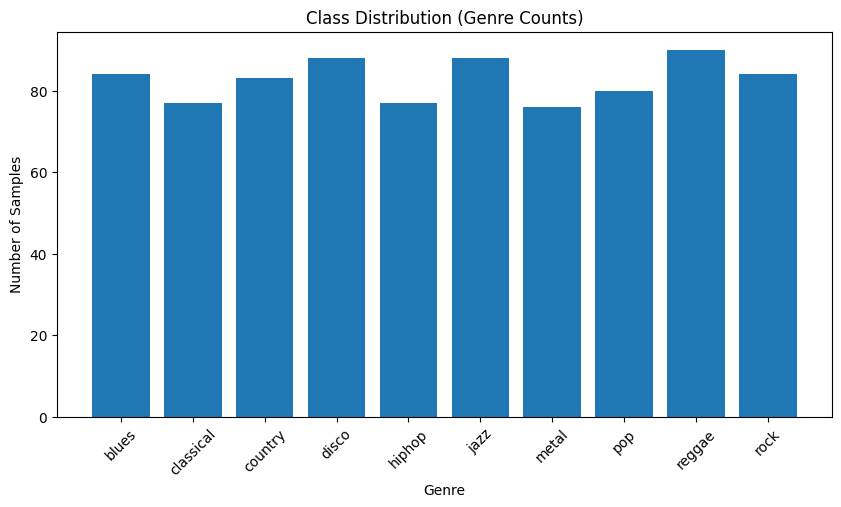

In [14]:
df = filtered_dataset.to_pandas()

# Convert to int
df['genre'] = df['genre'].astype(int)

# Count
counts = df['genre'].value_counts().sort_index()

# Map to names
genre_names = [dataset.features['genre'].int2str(i) for i in counts.index]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(genre_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (Genre Counts)")
plt.xlabel("Genre")
plt.ylabel("Number of Samples")
plt.show()

In [15]:
import pandas as pd

# Convert dataset to pandas once
df = filtered_dataset.to_pandas()

# Count by genre ID
counts = df["genre"].value_counts().sort_index()

# Get genre names from dataset features
genre_names = filtered_dataset.features["genre"].names

# Convert to name-based table
table = pd.DataFrame({
    "genre_id": counts.index,
    "genre_name": [genre_names[i] for i in counts.index],
    "count": counts.values
}).sort_values("count", ascending=False)

print(table)


   genre_id genre_name  count
8         8     reggae     90
3         3      disco     88
5         5       jazz     88
0         0      blues     84
9         9       rock     84
2         2    country     83
7         7        pop     80
1         1  classical     77
4         4     hiphop     77
6         6      metal     76


Now there is some mild class imbalance, that I will later correct through the use of the oversampling technique

# FEATURE EXTRACTION

### **Mel Frequency Cepstral Coefficients**

**[Mel Frequency Cepstral Coefficients (MFCCs)](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum)** are commonly used in audio analysis to capture key features of sound. They help represent the important characteristics of an audio signal, making them ideal for tasks like music genre classification and speech recognition.

We're not going to dive deep into the complex details of audio processing, but it's useful to know that MFCCs help simplify raw audio data while retaining important information.

#### Basic Steps in MFCC Extraction:
1. **Frequency Domain Conversion**: The audio signal is split into short frames, and we apply the Fourier Transform to convert them from the time domain to the frequency domain.
2. **Mel Scale Mapping**: The frequency spectrum is converted to the Mel scale, which better represents how humans perceive sound, emphasizing lower frequencies.
3. **Logarithm and DCT**: After mapping to the Mel scale, we apply a logarithm and the Discrete Cosine Transform (DCT) to get the MFCCs. These summarize the "cepstral" information of the audio signal.

The parameter `n_mfcc` controls **how many MFCC coefficients** are extracted for each frame. For example, setting `n_mfcc=8` means we extract 8 coefficients, where lower coefficients capture broad audio features, and higher coefficients capture the more finer details.

In this notebook, we'll use the **mean** and **variance** of the MFCCs over time to create a robust feature set for our classification model. Adjusting the `n_mfcc` parameter allows us to control the number of features extracted for each audio sample.

#### **Additional Features**
Consider exploring additional audio features to enhance your model's performance. There are various acoustic properties you could extract from the audio signals, such as zero crossings, harmonic-percussive separation, tempo, spectral centroids, spectral rolloff, chromagram, RMS energy, spectral bandwidth, etc. When working with these features, it's often useful to compute summary statistics like the mean and variance across the audio sample. These summary statistics can capture the overall characteristics and variability of the feature, reducing the dimensionality of your data while retaining important information. Experimenting with these features and their statistical summaries could potentially improve your model's accuracy and robustness in distinguishing between different audio characteristics.

#### **Feature Analysis**
Don´t forget to optimize the use of features, identifying and handling irrelevant and reduntant features. Then use feature ranking to identify which features are more influential, and evaluate quantitatively how many top-features to retain.

### TOTAL FEATURES EXTRACTED : 

- MFCC (Mel‑Frequency Cepstral Coefficients): captures the timbre of the sound, - similar to how humans perceive tone color. 

- RMS (Root Mean Square Energy): measures loudness and overall signal strength.

- Spectral Contrast: highlights differences between peaks and valleys in the spectrum, useful for identifying texture and brightness.

- Zero‑Crossing Rate: counts how often the signal changes sign, indicating noisiness or percussive content.

- Spectral Centroid: represents the “center of mass” of the spectrum, perceived as brightness of the sound.

- Spectral Rolloff: frequency below which most of the energy is concentrated, distinguishing smooth vs. sharp sounds.

- Chroma Frequencies: summarize harmonic and pitch‑class information, capturing chords and tonality.

- Spectral Band Energy: measures how energy is distributed across low, mid, and high bands, useful for genre‑specific frequency profiles.

- Tempo and Beat Features: describe the rhythmic structure, helping differentiate genres with characteristic tempos or beat patterns.

In [16]:
def extract_mfcc_features(dataset, n_mfcc):
    mfcc_features = []

    # here we might have used Dataset.map method, unfortunately, it consumes extra memory and runs out of RAM in colab
    for entry in tqdm(dataset, desc="Extracting MFCC Features"):
        audio_array = entry['audio']['array']
        sampling_rate = entry['audio']['sampling_rate']

        mfcc = librosa.feature.mfcc(y=audio_array, sr=sampling_rate, n_mfcc=n_mfcc)

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_var = np.var(mfcc, axis=1)

        feature_dict = {}

        for i in range(n_mfcc):
            feature_dict[f'mfcc_mean{i+1}'] = mfcc_mean[i]
            feature_dict[f'mfcc_var{i+1}'] = mfcc_var[i]

        feature_dict['genre'] = entry['genre']

        mfcc_features.append(feature_dict)

    return pd.DataFrame(mfcc_features)

In [17]:
# Store all MFCC dataframes in a dict
dfs_mfcc = {}
for n in [8, 13, 20]:
    df_mfcc = extract_mfcc_features(filtered_dataset, n_mfcc=n)
    dfs_mfcc[n] = df_mfcc
    print(n, df_mfcc.shape)

Extracting MFCC Features:   0%|          | 0/827 [00:00<?, ?it/s]

Extracting MFCC Features: 100%|██████████| 827/827 [01:52<00:00,  7.32it/s]


8 (827, 17)


Extracting MFCC Features: 100%|██████████| 827/827 [02:00<00:00,  6.84it/s]


13 (827, 27)


Extracting MFCC Features: 100%|██████████| 827/827 [01:54<00:00,  7.23it/s]

20 (827, 41)


Let's take a look at the output of the function. We will pass there just 2 samples from the dataset.

In [18]:
extract_mfcc_features(dataset.select(range(2)), n_mfcc=5)

Extracting MFCC Features: 100%|██████████| 2/2 [00:00<00:00,  6.50it/s]


,mfcc_mean1,mfcc_var1,mfcc_mean2,mfcc_var2,mfcc_mean3,mfcc_var3,mfcc_mean4,mfcc_var4,mfcc_mean5,mfcc_var5,genre
0,-69.836278,2341.101347,124.207701,580.461335,-32.482371,329.799566,47.689801,167.005379,1.400885,125.102031,2
1,-191.643297,3301.314391,41.318241,403.273174,5.013655,447.922087,65.453821,220.996266,-4.320506,210.413597,4


The function generates `n_mfcc * 2` features for each sample. Consider analyzing their correlation with a matrix and experimenting with different `n_mfcc` values to observe how feature relationships change. While MFCC features are effective for audio analysis, you might also improve performance by incorporating additional features such as RMS or Spectral Contrast. Once you've explored these options, proceed to training the model using the extracted features.

I want to check which n_mfcc is best to keep.

In [19]:
results = []

for n_mfcc, df_mfcc in dfs_mfcc.items():
    df = df_mfcc.copy()
    df["genre"] = df["genre"].astype(int)

    X = df.drop(columns=["genre"]).values
    y = df["genre"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=5000, random_state=42))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "n_mfcc": n_mfcc,
        "test_acc": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro")
    })

results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
print(results_df)

   n_mfcc  test_acc  test_f1_macro
2      20  0.644578       0.642605
1      13  0.620482       0.620803
0       8  0.596386       0.592371


n_mfcc = 20 performs best

#  CORRELATION MATRIX  

If mfcc_meanX and mfcc_varX are strongly correlated, then they carry very similar information, so one of them might be unnecessary.

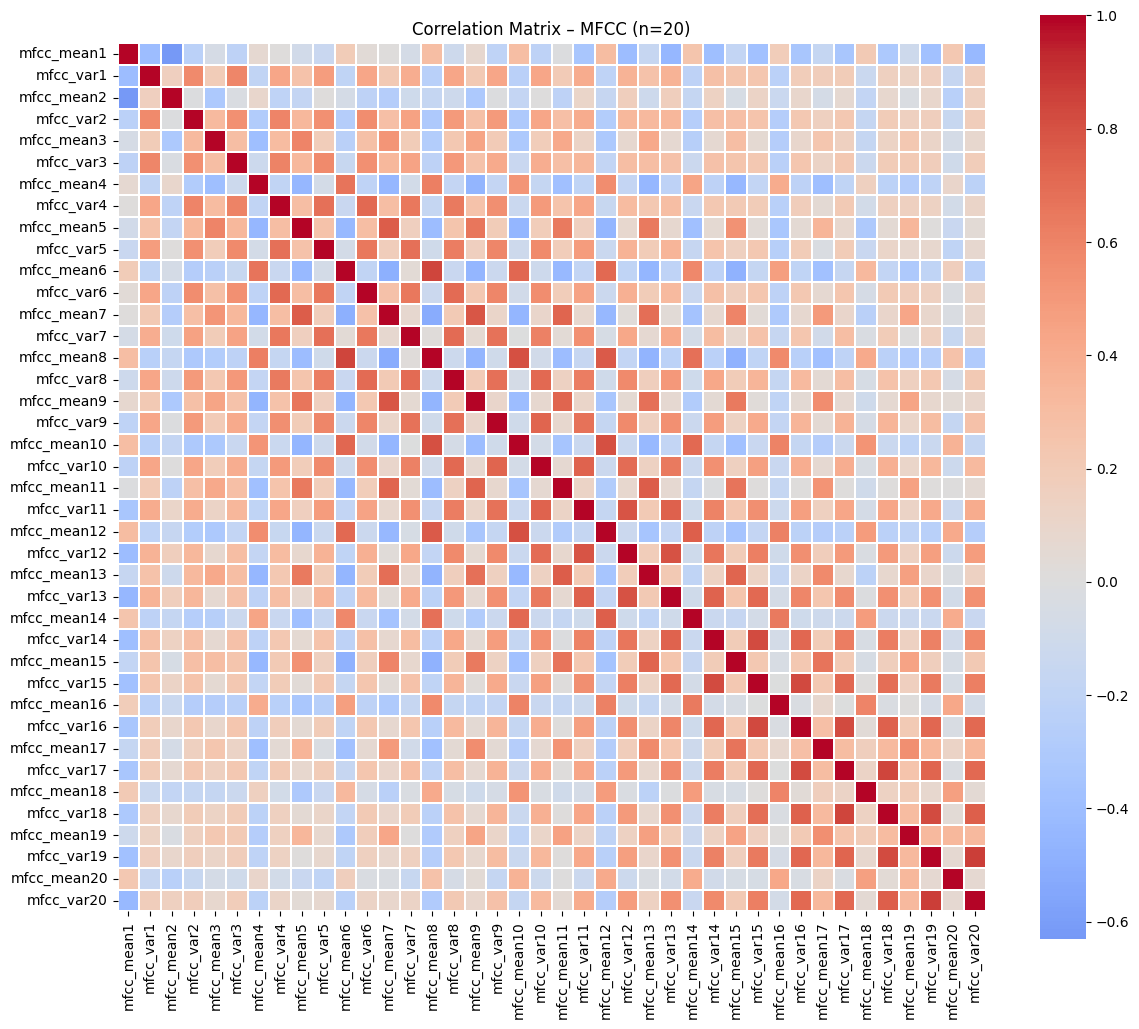

In [20]:
# select MFCC = 20
df_corr = dfs_mfcc[20].copy()
df_corr["genre"] = df_corr["genre"].astype(int)

# drop label
X_corr = df_corr.drop(columns=["genre"])

# correlation matrix
corr = X_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2
)
plt.title("Correlation Matrix – MFCC (n=20)")
plt.show()

In [21]:
# --- prepare train matrix (same as before) ---
df_best = dfs_mfcc[20].copy()
df_best["genre"] = df_best["genre"].astype(int)

X = df_best.drop(columns=["genre"])
y = df_best["genre"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

# --- correlation matrix ---
df_train_os = pd.DataFrame(X_train_os, columns=X.columns)
corr = df_train_os.corr().abs()

# --- get top correlated pairs ---
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
        .sort_values("corr", ascending=False)
)

# show top 20
top20 = pairs.head(20)
print(top20)


       feature_1    feature_2      corr
778   mfcc_var19   mfcc_var20  0.861310
760   mfcc_var17   mfcc_var18  0.848156
348   mfcc_mean6   mfcc_mean8  0.845236
726   mfcc_var15   mfcc_var16  0.834426
703   mfcc_var14   mfcc_var15  0.833858
771   mfcc_var18   mfcc_var19  0.828085
458   mfcc_mean8  mfcc_mean10  0.826532
745   mfcc_var16   mfcc_var17  0.820332
645   mfcc_var12   mfcc_var13  0.818072
552  mfcc_mean10  mfcc_mean12  0.815063
405   mfcc_mean7   mfcc_mean9  0.800072
610   mfcc_var11   mfcc_var12  0.794192
593  mfcc_mean11  mfcc_mean13  0.787285
462   mfcc_mean8  mfcc_mean12  0.776754
287   mfcc_mean5   mfcc_mean7  0.761935
612   mfcc_var11   mfcc_var13  0.758378
528    mfcc_var9   mfcc_var10  0.754266
663  mfcc_mean13  mfcc_mean15  0.753860
773   mfcc_var18   mfcc_var20  0.749475
630  mfcc_mean12  mfcc_mean14  0.747566


Many features are highly correlated. The next step is to check whether removing highly correlated features will improve the accuracy. The threshold set is >0.80

In [22]:
def remove_correlated_features(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop

# --- remove features ---
X_train_clean, dropped = remove_correlated_features(df_train_os, threshold=0.8)

print("Dropped features:", dropped)
print("Remaining features:", X_train_clean.shape[1])

# apply same drop to test set
X_test_clean = pd.DataFrame(X_test, columns=X.columns).drop(columns=dropped)

def run_logistic(X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=42))
    ])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    return accuracy_score(y_te, y_pred)

acc_before = run_logistic(df_train_os, y_train_os, X_test, y_test)
acc_after  = run_logistic(X_train_clean, y_train_os, X_test_clean, y_test)

print("\nLogistic Regression accuracy:")
print("Before removal:", acc_before)
print("After removal:", acc_after)


Dropped features: ['mfcc_mean8', 'mfcc_mean9', 'mfcc_mean10', 'mfcc_mean12', 'mfcc_var13', 'mfcc_var15', 'mfcc_var16', 'mfcc_var17', 'mfcc_var18', 'mfcc_var19', 'mfcc_var20']
Remaining features: 29

Logistic Regression accuracy:
Before removal: 0.6506024096385542
After removal: 0.6325301204819277


Removing correlated features reduced accuracy. This means that those features can still be informative.

## RMS, SPECTRAL CONTRAST

**Implement functions to extract RMS and Spectral Contrast (10 points in total)**

Write functions to extract these features, also add their description and discuss why they might be useful in this assignment.

## SPECTRAL CONTRAST

Spectral contrast is an audio feature that measures the difference in energy between the peaks and valleys of the frequency spectrum. Unlike MFCCs, which describe the general shape of the spectral envelope, spectral contrast focuses on the contrast between high-energy and low-energy frequency bands. This makes it particularly effective for capturing the harmonic structure and timbral characteristics of audio signals.

In the context of music genre classification, spectral contrast provides complementary information to MFCCs. MFCCs primarily capture overall spectral shape and broad tonal features, whereas spectral contrast is more sensitive to instrumentation and percussive vs harmonic content. For example, genres such as classical or jazz typically exhibit clearer harmonic structure (higher contrast), while electronic and hip-hop music often show less contrast due to strong bass and noisy components.

Therefore, incorporating spectral contrast into the feature set can improve classification performance by adding information about harmonic richness, brightness, and percussiveness, which are often key differentiators between musical genres. In summary, spectral contrast is a valuable addition to MFCC features because it enhances the model’s ability to distinguish genres based on timbre and sound texture.

### Demonstrative plot

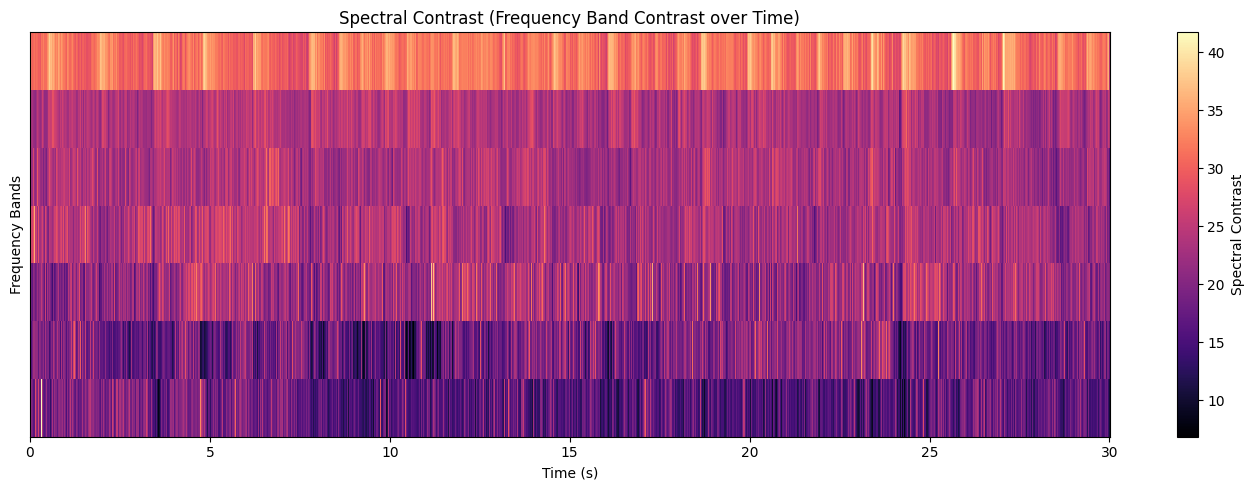

In [23]:
entry = filtered_dataset[0]
x = entry["audio"]["array"]
sr = entry["audio"]["sampling_rate"]

# Compute spectral contrast
spectral_contrast = librosa.feature.spectral_contrast(y=x, sr=sr)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    spectral_contrast,
    x_axis="time",
    cmap="magma"
)
plt.colorbar(label="Spectral Contrast")
plt.title("Spectral Contrast (Frequency Band Contrast over Time)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency Bands")
plt.tight_layout()
plt.show()


How to read the plot:
Y-axis → frequency bands (low → high)
Color intensity → contrast strength:
- bright = strong peak–valley separation
- dark = flat/noisy spectrum

Genre intuition:
- Classical / Jazz → strong contrast in low–mid bands (harmonics, instruments)
- Metal / Rock → reduced contrast (distortion fills valleys)
- HipHop / Reggae → strong low-band contrast (bass vs silence)

In [24]:
def extract_spectral_contrast(dataset, n_bands=6):
    contrast_features = []

    for entry in tqdm(dataset, desc="Extracting Spectral Contrast"):
        audio_array = entry['audio']['array']
        sampling_rate = entry['audio']['sampling_rate']

        contrast = librosa.feature.spectral_contrast(y=audio_array, sr=sampling_rate, n_bands=n_bands)

        # mean + var for each band
        contrast_mean = np.mean(contrast, axis=1)
        contrast_var = np.var(contrast, axis=1)

        feature_dict = {}
        for i in range(n_bands + 1):  # n_bands+1 bands returned by librosa
            feature_dict[f'contrast_mean{i+1}'] = contrast_mean[i]
            feature_dict[f'contrast_var{i+1}'] = contrast_var[i]

        feature_dict['genre'] = entry['genre']
        contrast_features.append(feature_dict)

    return pd.DataFrame(contrast_features)

Checking if it works properly

In [25]:
df_spcon = extract_spectral_contrast(filtered_dataset)


Extracting Spectral Contrast: 100%|██████████| 827/827 [02:17<00:00,  6.00it/s]


In [26]:
# ===========================
# 1) NaN check
print("NaNs:", df_spcon.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_spcon.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_spcon.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_spcon.drop(columns=["genre"]).describe())

# 5) Feature variances
print("\nFeature variances:")
print(df_spcon.drop(columns=["genre"]).var())

# 6) Class-wise mean for all contrast bands
print("\nClass-wise mean for all contrast bands:")

n_bands = 6
for i in range(1, n_bands + 2):  # because bands = n_bands + 1
    col_mean = f"contrast_mean{i}"
    col_var = f"contrast_var{i}"

    print(f"\n--- Band {i} ---")
    print("Mean:", df_spcon.groupby("genre")[col_mean].mean())
    print("Var:", df_spcon.groupby("genre")[col_var].mean())

# 7) Min / Max values
print("\nMin / Max values:")
print(df_spcon.drop(columns=["genre"]).agg(["min", "max"]))

NaNs: 0
All finite: True
Shape: (827, 15)

Descriptive stats:
       contrast_mean1  contrast_var1  contrast_mean2  contrast_var2  \
count      827.000000     827.000000      827.000000     827.000000   
mean        21.747050      23.714595       16.305988      19.350095   
std          4.081089       7.651927        2.231013       5.536284   
min         13.499980       7.625196       11.713613       9.969447   
25%         18.811298      18.557081       14.721808      15.729565   
50%         20.971265      23.014134       15.905724      18.383236   
75%         24.364739      27.775056       17.627813      21.770008   
max         37.024049      61.696554       24.984341      70.721654   

       contrast_mean3  contrast_var3  contrast_mean4  contrast_var4  \
count      827.000000     827.000000      827.000000     827.000000   
mean        19.609557      21.541227       19.311659      16.072782   
std          2.654990       5.626841        2.666178       5.532230   
min         13

The extraction is correct and working.

## RMS

Root Mean Square (RMS) energy is a time-domain audio feature that measures the average power of an audio signal over short time frames. It is computed by squaring the signal amplitudes, averaging them within each frame, and taking the square root, which produces a stable and physically meaningful estimate of signal intensity. RMS effectively captures the loudness and dynamic behavior of audio, making it useful for distinguishing between music genres with different energy profiles. Its main strengths are robustness to signal fluctuations, low computational cost, and complementarity to spectral features such as MFCCs, as it encodes information about intensity and dynamics that frequency-based features do not capture.

RMS provides different information compared to MFCCs and spectral contrast because it operates in the time domain and focuses exclusively on signal energy rather than frequency content. While MFCCs describe the overall spectral shape and timbral characteristics of audio and spectral contrast captures differences between spectral peaks and valleys, both features are derived from the frequency domain and are largely insensitive to absolute loudness. In contrast, RMS encodes how strong or weak the audio signal is over time, capturing dynamic and intensity-related properties. This makes RMS complementary rather than redundant, as it adds information about energy and temporal variation that is not represented by spectral features, thereby enriching the overall feature set used for classification.

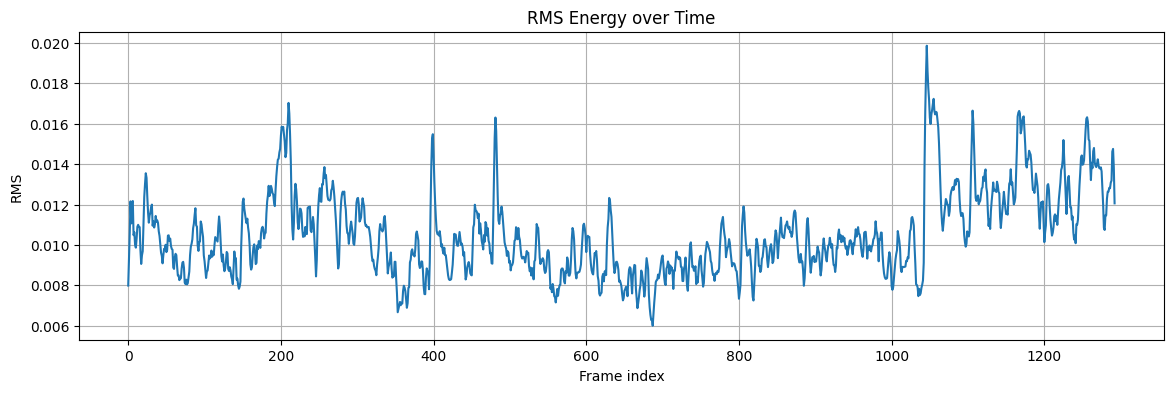

In [27]:
rms = librosa.feature.rms(y=x)[0]

plt.figure(figsize=(14, 4))
plt.plot(rms)
plt.title("RMS Energy over Time")
plt.xlabel("Frame index")
plt.ylabel("RMS")
plt.grid()
plt.show()


Spikes → loud sections (chorus, drops, distortion)

Valleys → silence, intros, breakdowns

Genres:
Metal / Rock → high, stable RMS
Classical / Jazz → wide RMS dynamics
HipHop / Pop → structured RMS patterns

In [28]:
def extract_rms_features(dataset):
    rms_features = []

    for entry in tqdm(dataset, desc="Extracting RMS Features"):
        audio_array = entry['audio']['array']
        sampling_rate = entry['audio']['sampling_rate']

        # Compute RMS over frames
        rms = librosa.feature.rms(y=audio_array)[0]

        feature_dict = {
            "rms_mean": np.mean(rms),
            "rms_var": np.var(rms),
            "genre": entry["genre"]
        }

        rms_features.append(feature_dict)

    return rms_features


Checking that it works:

In [29]:
# --- Extract RMS features ---
df_rms = pd.DataFrame(extract_rms_features(filtered_dataset))

# 1) Basic checks
print("NaNs:", df_rms.isna().sum().sum())
print("All finite:", np.isfinite(df_rms.drop(columns=["genre"])).all().all())
print("Shape:", df_rms.shape)

# 2) Descriptive statistics
print("\nDescriptive stats:")
print(df_rms.drop(columns=["genre"]).describe())

# 3) Variance check (low-variance features)
print("\nFeature variances:")
print(df_rms.drop(columns=["genre"]).var())

# 4) Class-wise mean (quick discriminative sanity check)
print("\nClass-wise RMS mean:")
print(df_rms.groupby("genre")[["rms_mean"]].mean())

# 5) Value range sanity check
print("\nMin / Max values:")
print(df_rms.drop(columns=["genre"]).agg(["min", "max"]))


Extracting RMS Features: 100%|██████████| 827/827 [00:21<00:00, 37.64it/s]


NaNs: 0
All finite: True
Shape: (827, 3)

Descriptive stats:
         rms_mean     rms_var
count  827.000000  827.000000
mean     0.129884    0.002961
std      0.063751    0.003501
min      0.006627    0.000004
25%      0.087794    0.000943
50%      0.120015    0.001822
75%      0.172703    0.003494
max      0.397734    0.027704

Feature variances:
rms_mean    0.004064
rms_var     0.000012
dtype: float32

Class-wise RMS mean:
       rms_mean
genre          
0      0.133839
1      0.043561
2      0.123417
3      0.137688
4      0.178278
5      0.088679
6      0.155617
7      0.201356
8      0.116846
9      0.124697

Min / Max values:
     rms_mean   rms_var
min  0.006627  0.000004
max  0.397734  0.027704


The feature extraction is working properly.

**Explore and add other features useful for classification (10 points)**

It can be in a single function or in separated functions. Select some features and provide a description for each one. You can choose as many features as you like.

## ZERO CROSSING  

**Zero Crossing Rate (ZCR)** measures how frequently an audio signal changes sign, meaning how often the waveform crosses the zero-amplitude axis from positive to negative or vice versa. Because audio signals naturally oscillate around zero, each crossing reflects a rapid change in the signal’s shape. Signals with a lot of high-frequency content, noise, or sharp transients tend to cross zero more often, resulting in a high ZCR, while smoother, more harmonic and tonal signals cross zero less frequently, producing a low ZCR. For this reason, ZCR is commonly used to capture the percussive and noisy characteristics of sound. In music genre classification, rhythm-driven and aggressive genres such as Metal, Hip-Hop, and Disco typically exhibit higher ZCR values due to fast beats and abrupt signal changes, whereas Classical, Jazz, and Blues generally show lower ZCR values because of their smoother, sustained harmonic structures. As a result, ZCR is a useful feature for distinguishing energetic, percussive genres from more melodic and harmonic ones.


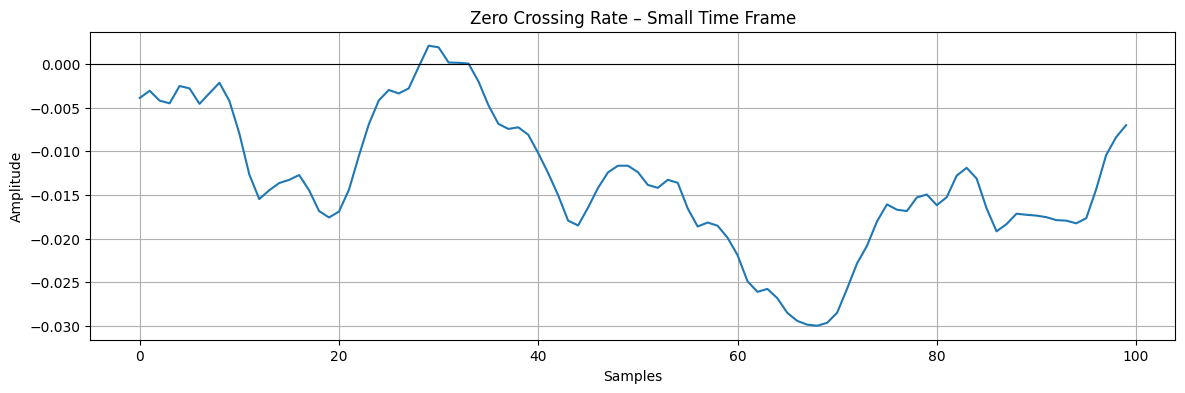

Zero crossings in this frame: 2


In [30]:
#demonstrative plot

# take one sample from the filtered dataset
entry = filtered_dataset[0]
x = entry["audio"]["array"]
sr = entry["audio"]["sampling_rate"]

# short frame for visualization
m0 = 10000
m1 = 10100

plt.figure(figsize=(14, 4))
plt.plot(x[m0:m1])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Zero Crossing Rate – Small Time Frame")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# compute zero crossings in the frame
zcr_frame = librosa.zero_crossings(x[m0:m1], pad=False)
print(f"Zero crossings in this frame: {np.sum(zcr_frame)}")

In [31]:
def extract_zcr_features(dataset):
    zcr_features = []

    for entry in tqdm(dataset, desc="Extracting ZCR Features"):
        audio_array = entry["audio"]["array"]

        # Compute ZCR per frame
        zcr = librosa.feature.zero_crossing_rate(y=audio_array)[0]

        feature_dict = {
            "zcr_mean": np.mean(zcr),
            "zcr_var": np.var(zcr),
            "genre": entry["genre"]
        }

        zcr_features.append(feature_dict)

    return pd.DataFrame(zcr_features)


Checking if it works

In [32]:
# ---- RUN TESTS ----
df_zcr = extract_zcr_features(filtered_dataset)

# 1) NaN check
print("NaNs:", df_zcr.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_zcr.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_zcr.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_zcr.drop(columns=["genre"]).describe())

# 5) Feature variance
print("\nFeature variances:")
print(df_zcr.drop(columns=["genre"]).var().astype(np.float32))

# 6) Class-wise mean
print("\nClass-wise ZCR mean:")
print(df_zcr.groupby("genre")[["zcr_mean"]].mean())

# 7) Min/Max values
print("\nMin / Max values:")
print(df_zcr.drop(columns=["genre"]).agg(["min", "max"]))


Extracting ZCR Features: 100%|██████████| 827/827 [00:29<00:00, 27.72it/s]


NaNs: 0
All finite: True
Shape: (827, 3)

Descriptive stats:
         zcr_mean     zcr_var
count  827.000000  827.000000
mean     0.102833    0.002956
std      0.040941    0.002997
min      0.021697    0.000111
25%      0.069822    0.001053
50%      0.098348    0.002022
75%      0.131453    0.003587
max      0.274631    0.028718

Feature variances:
zcr_mean    0.001676
zcr_var     0.000009
dtype: float32

Class-wise ZCR mean:
       zcr_mean
genre          
0      0.079278
1      0.078927
2      0.083485
3      0.130504
4      0.108178
5      0.076300
6      0.146331
7      0.133076
8      0.088608
9      0.108408

Min / Max values:
     zcr_mean   zcr_var
min  0.021697  0.000111
max  0.274631  0.028718


The feature extraction is working properly.

## SPECTRAL CENTROID  

**Spectral Centroid** is a measure that describes the “center of mass” of an audio signal’s frequency spectrum, indicating where most of the spectral energy is concentrated. To compute it, the audio is transformed into the frequency domain using the Fast Fourier Transform (FFT), producing a set of frequency bins each with a corresponding magnitude. The centroid is calculated by taking a weighted average of the frequencies, where the weights are the magnitudes of each bin. This means that higher-frequency components with greater energy pull the centroid upward, while lower-frequency energy keeps it lower. As a result, the spectral centroid is closely related to the perceived brightness of a sound: a high centroid corresponds to bright, sharp, high-frequency dominant timbres, while a low centroid corresponds to darker, bass-heavy, low-frequency dominant timbres. In genre classification, this feature helps distinguish between music styles that emphasize high-energy, bright sounds (such as Metal, Rock, and Pop) and those that tend to be warmer and more mellow (such as Blues, Classical, and Jazz). Thus, spectral centroid effectively separates bright versus dark sonic textures across genres.


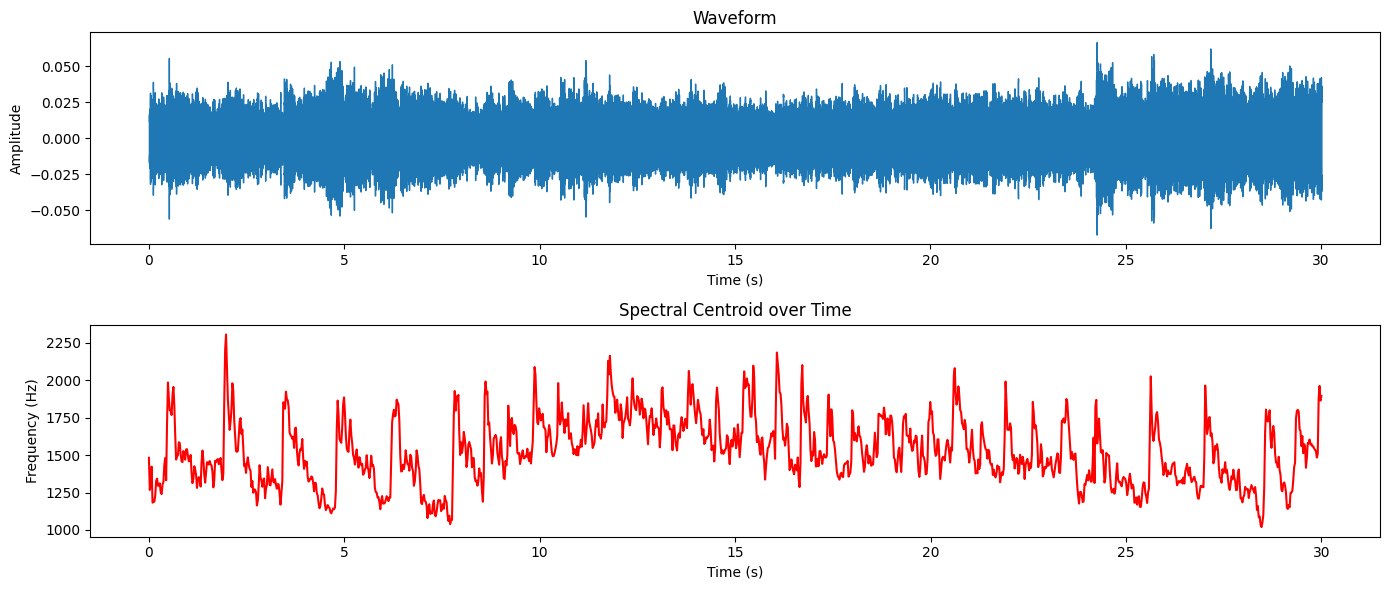

In [33]:
#demonstrative plot

entry = filtered_dataset[0]
x = entry["audio"]["array"]
sr = entry["audio"]["sampling_rate"]

# Compute spectral centroid
centroid = librosa.feature.spectral_centroid(y=x, sr=sr)[0]

# Time axis
frames = range(len(centroid))
t = librosa.frames_to_time(frames, sr=sr)

plt.figure(figsize=(14, 6))

# Waveform
plt.subplot(2, 1, 1)
librosa.display.waveshow(x, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Spectral centroid
plt.subplot(2, 1, 2)
plt.plot(t, centroid, color="r")
plt.title("Spectral Centroid over Time")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()


Peaks in centroid → moments with more high-frequency content

Flat low curve → bass-dominated or smooth passages

This plot makes it obvious why centroid ≠ RMS:

RMS = how strong

Centroid = where in frequency

In [34]:
def extract_spectral_centroid_features(dataset):
    centroid_features = []

    for entry in tqdm(dataset, desc="Extracting Spectral Centroid"):
        x = entry["audio"]["array"]
        sr = entry["audio"]["sampling_rate"]

        centroid = librosa.feature.spectral_centroid(y=x, sr=sr)[0]

        feature_dict = {
            "centroid_mean": np.mean(centroid),
            "centroid_var": np.var(centroid),
            "genre": entry["genre"]
        }

        centroid_features.append(feature_dict)

    return pd.DataFrame(centroid_features)


Checking that it works

In [35]:
df_centroid = extract_spectral_centroid_features(filtered_dataset)

# 1) NaN check
print("NaNs:", df_centroid.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_centroid.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_centroid.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_centroid[['centroid_mean', 'centroid_var']].describe())

# 5) Feature variances
print("\nFeature variances:")
print(df_centroid[['centroid_mean', 'centroid_var']].var())

# 6) Class-wise centroid mean
print("\nClass-wise centroid mean:")
print(df_centroid.groupby("genre")["centroid_mean"].mean())

# 7) Min / Max
print("\nMin / Max values:")
print(df_centroid[['centroid_mean', 'centroid_var']].agg(["min", "max"]))


Extracting Spectral Centroid: 100%|██████████| 827/827 [02:17<00:00,  6.01it/s]


NaNs: 0
All finite: True
Shape: (827, 3)

Descriptive stats:
       centroid_mean  centroid_var
count     827.000000  8.270000e+02
mean     2202.813299  4.661296e+05
std       703.554276  3.888196e+05
min       570.349904  1.485809e+04
25%      1620.109499  1.868936e+05
50%      2209.486740  3.380934e+05
75%      2684.455505  6.082486e+05
max      4281.984674  2.601903e+06

Feature variances:
centroid_mean    4.949886e+05
centroid_var     1.511807e+11
dtype: float64

Class-wise centroid mean:
genre
0    1739.589506
1    1379.352928
2    1887.719472
3    2652.177497
4    2546.456498
5    1804.543622
6    2597.630861
7    3074.694904
8    2135.173699
9    2248.576288
Name: centroid_mean, dtype: float64

Min / Max values:
     centroid_mean  centroid_var
min     570.349904  1.485809e+04
max    4281.984674  2.601903e+06


The feature extraction is working properly.

## SPECTRAL ROLLOFF  

**Spectral Rolloff** is a spectral feature that identifies the frequency below which a specified percentage of the total spectral energy is contained. In other words, it marks the cutoff frequency that separates the bulk of the sound’s energy from the higher-frequency tail. This makes rolloff a useful indicator of how much high-frequency content a signal contains: a higher rolloff value means that a larger portion of the energy is located in higher frequencies, while a lower rolloff indicates that most energy is concentrated in lower frequencies. Compared to spectral centroid, rolloff is often more robust to noise and outliers because it is based on energy accumulation rather than an average of all frequency magnitudes. In genre classification, spectral rolloff helps distinguish bright, high-energy genres such as Metal, Hip-Hop, and Disco—which tend to have higher rolloff values—from smoother, more harmonic genres like Classical, Jazz, and Blues, which typically have lower rolloff values. Thus, spectral rolloff provides a reliable measure of timbral brightness and high-frequency emphasis.


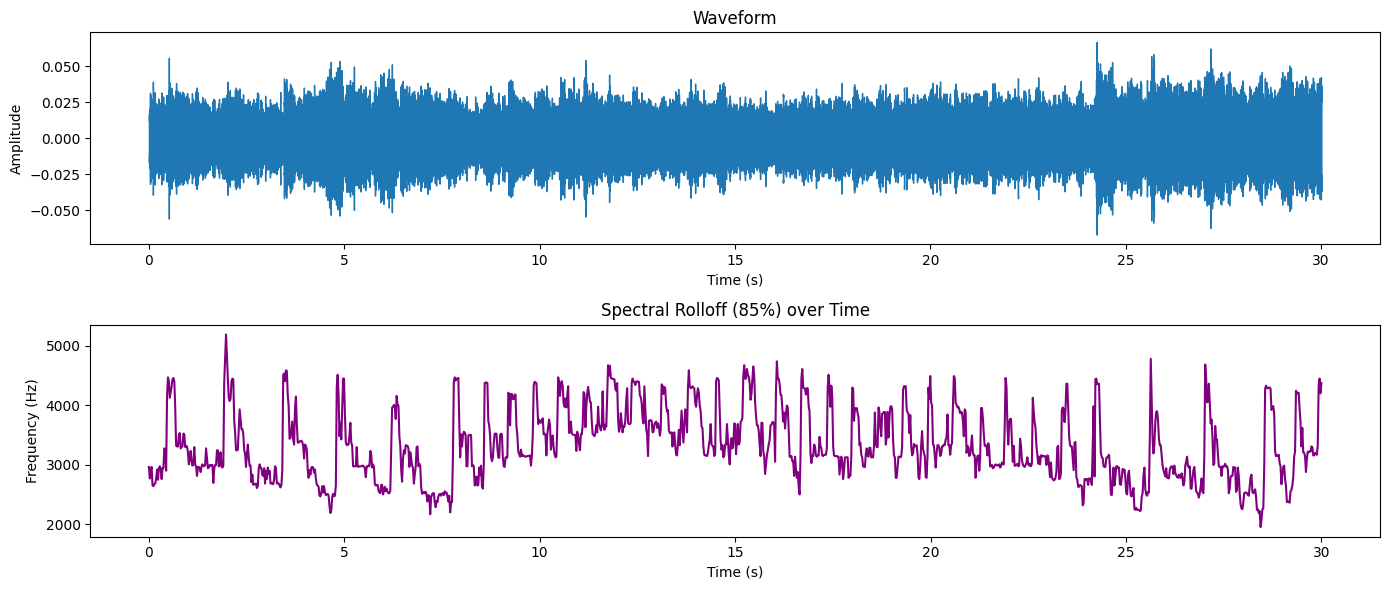

In [36]:
#demonstrative plot

entry = filtered_dataset[0]
x = entry["audio"]["array"]
sr = entry["audio"]["sampling_rate"]

# Spectral rolloff
rolloff = librosa.feature.spectral_rolloff(y=x, sr=sr, roll_percent=0.85)[0]

t = librosa.frames_to_time(range(len(rolloff)), sr=sr)

plt.figure(figsize=(14, 6))

# Waveform
plt.subplot(2, 1, 1)
librosa.display.waveshow(x, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Rolloff
plt.subplot(2, 1, 2)
plt.plot(t, rolloff, color="purple")
plt.title("Spectral Rolloff (85%) over Time")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

In [37]:
def extract_spectral_rolloff_features(dataset, roll_percent=0.85):
    rolloff_features = []

    for entry in tqdm(dataset, desc="Extracting Spectral Rolloff"):
        x = entry["audio"]["array"]
        sr = entry["audio"]["sampling_rate"]

        rolloff = librosa.feature.spectral_rolloff(
            y=x, sr=sr, roll_percent=roll_percent
        )[0]

        feature_dict = {
            "rolloff_mean": np.mean(rolloff),
            "rolloff_var": np.var(rolloff),
            "genre": entry["genre"]
        }

        rolloff_features.append(feature_dict)

    return pd.DataFrame(rolloff_features)


Checking that it works

In [38]:
df_rolloff = extract_spectral_rolloff_features(filtered_dataset)

# 1) NaN check
print("NaNs:", df_rolloff.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_rolloff.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_rolloff.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_rolloff[['rolloff_mean', 'rolloff_var']].describe())

# 5) Feature variances
print("\nFeature variances:")
print(df_rolloff[['rolloff_mean', 'rolloff_var']].var())

# 6) Class-wise rolloff mean
print("\nClass-wise rolloff mean:")
print(df_rolloff.groupby("genre")["rolloff_mean"].mean())

# 7) Min / Max
print("\nMin / Max values:")
print(df_rolloff[['rolloff_mean', 'rolloff_var']].agg(["min", "max"]))


Extracting Spectral Rolloff: 100%|██████████| 827/827 [02:00<00:00,  6.88it/s]

NaNs: 0
All finite: True
Shape: (827, 3)

Descriptive stats:
       rolloff_mean   rolloff_var
count    827.000000  8.270000e+02
mean    4593.090183  1.838552e+06
std     1548.083031  1.394562e+06
min      929.308431  7.591046e+04
25%     3420.710857  7.813318e+05
50%     4683.230201  1.489286e+06
75%     5549.417036  2.575730e+06
max     8483.382577  8.308329e+06

Feature variances:
rolloff_mean    2.396561e+06
rolloff_var     1.944802e+12
dtype: float64

Class-wise rolloff mean:
genre
0    3676.405550
1    2561.910325
2    3926.001263
3    5594.939030
4    5402.981901
5    3793.234036
6    5142.846680
7    6657.339786
8    4512.673521
9    4699.634903
Name: rolloff_mean, dtype: float64

Min / Max values:
     rolloff_mean   rolloff_var
min    929.308431  7.591046e+04
max   8483.382577  8.308329e+06


The feature extraction is working properly.

## CHROMA FREQUENCIES  

Chroma Frequencies (Chroma Features) capture the distribution of pitch classes in an audio signal, summarizing musical content in terms of the twelve semitones of the Western scale. To compute chroma, the audio spectrum is mapped into 12 bins, each corresponding to one of the twelve pitch classes (C, C♯/D♭, D, …, B). Energy from all frequencies that belong to the same pitch class is accumulated into the corresponding bin, creating a compact representation of harmonic content that is largely invariant to octave changes. This makes chroma particularly effective at representing chord structures, tonal centers, and harmonic progressions. Signals with clear, stable harmony (e.g., strong chords and consistent tonality) generate pronounced chroma patterns, while percussive or noisy genres tend to produce weaker or less stable chroma profiles. In genre classification, chroma features are useful because they emphasize harmonic consistency: genres such as Classical, Jazz, Blues, and Reggae—where chord progressions and tonal structure are prominent—usually exhibit strong chroma signals, whereas rhythm-driven genres like Metal, Hip-Hop, and Disco typically show weaker chroma patterns. Overall, chroma features help distinguish music based on tonal and harmonic characteristics rather than purely on timbre or rhythm.

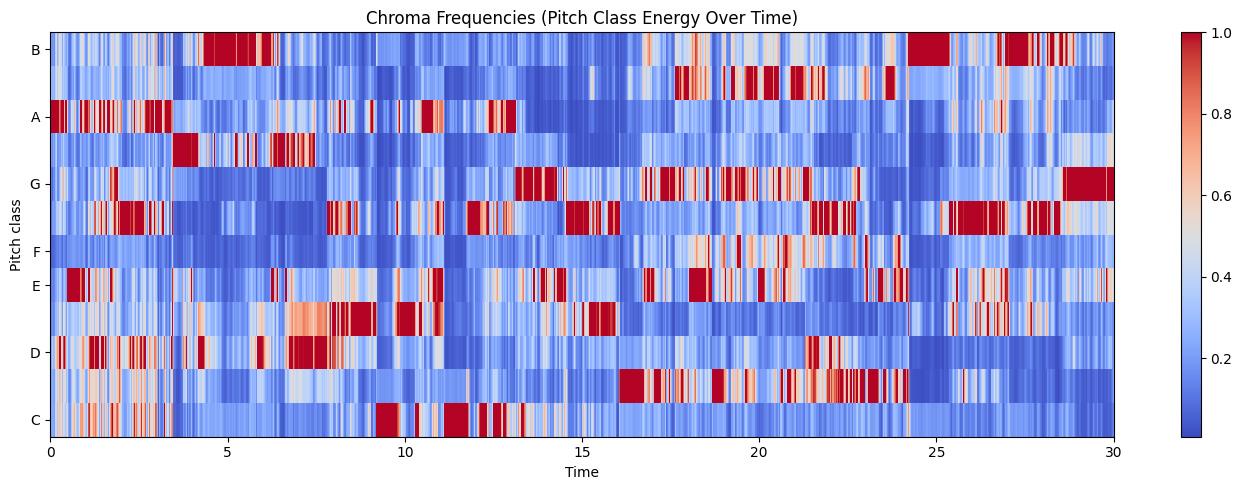

In [39]:
#demonstrative plot  

# load one example
entry = filtered_dataset[0]
y = entry["audio"]["array"]
sr = entry["audio"]["sampling_rate"]

# compute chroma
chroma = librosa.feature.chroma_stft(y=y, sr=sr)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    chroma,
    x_axis="time",
    y_axis="chroma",
    cmap="coolwarm"
)
plt.colorbar()
plt.title("Chroma Frequencies (Pitch Class Energy Over Time)")
plt.tight_layout()
plt.show()

Y-axis → pitch classes (C → B)

X-axis → time

Color → energy of that pitch class

Horizontal stable bands → strong harmonic structure

Chaotic patterns → percussive / noisy genres

In [40]:
def extract_chroma_features(dataset):
    chroma_features = []

    for entry in tqdm(dataset, desc="Extracting Chroma Features"):
        y = entry["audio"]["array"]
        sr = entry["audio"]["sampling_rate"]

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        chroma_mean = np.mean(chroma, axis=1)
        chroma_var = np.var(chroma, axis=1)

        feature_dict = {}

        for i in range(12):
            feature_dict[f"chroma_mean{i+1}"] = chroma_mean[i]
            feature_dict[f"chroma_var{i+1}"] = chroma_var[i]

        feature_dict["genre"] = entry["genre"]

        chroma_features.append(feature_dict)

    return pd.DataFrame(chroma_features)


Checking that it works

In [41]:
df_chroma = pd.DataFrame(extract_chroma_features(filtered_dataset))

# 1) NaN check
print("NaNs:", df_chroma.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_chroma.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_chroma.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_chroma.drop(columns=["genre"]).describe())

# 5) Feature variances
print("\nFeature variances:")
print(df_chroma.drop(columns=["genre"]).var())

# 6) Class-wise mean (example using chroma_mean1)
print("\nClass-wise chroma_mean1:")
print(df_chroma.groupby("genre")["chroma_mean1"].mean())

# 7) Min / Max values
print("\nMin / Max values:")
print(df_chroma.drop(columns=["genre"]).agg(["min", "max"]))


Extracting Chroma Features: 100%|██████████| 827/827 [03:11<00:00,  4.33it/s]

NaNs: 0
All finite: True
Shape: (827, 25)

Descriptive stats:
       chroma_mean1  chroma_var1  chroma_mean2  chroma_var2  chroma_mean3  \
count    827.000000   827.000000    827.000000   827.000000    827.000000   
mean       0.382760     0.085818      0.358373     0.070167      0.391139   
std        0.111037     0.028730      0.113843     0.024266      0.116970   
min        0.047439     0.005220      0.078052     0.008850      0.101406   
25%        0.308578     0.065419      0.276654     0.053920      0.317959   
50%        0.377741     0.084353      0.359222     0.068603      0.391627   
75%        0.452947     0.104815      0.429025     0.084981      0.469192   
max        0.786571     0.189808      0.806371     0.140043      0.773714   

       chroma_var3  chroma_mean4  chroma_var4  chroma_mean5  chroma_var5  ...  \
count   827.000000    827.000000   827.000000    827.000000   827.000000  ...   
mean      0.085982      0.371438     0.074855      0.388089     0.082114  ...   
s

The feature extraction is working properly.

## SPECTRAL BAND ENERGY  

Spectral Band Energy quantifies the total amount of energy contained within predefined frequency bands of an audio signal. By dividing the spectrum into several ranges (e.g., bass, low mid, mid, high mid, and treble), this feature provides a compact representation of how energy is distributed across the frequency spectrum.
Typical band definitions:

Band	    Frequency Range
Bass	    0–250 Hz
Low Mid 	250–500 Hz
Mid	        500–2000 Hz
High Mid	2000–6000 Hz
Treble	    6000–12000 Hz

To compute spectral band energy, the audio signal is first transformed into the frequency domain using the Short-Time Fourier Transform (STFT), producing a magnitude spectrum for each time frame. For each predefined band, the magnitudes of all frequency bins within that range are summed to obtain the band’s energy in each frame. These values are then averaged across all frames to create a stable feature representing the overall energy distribution in that band. This method captures the tonal balance of a track, making it useful for distinguishing genres: for example, Hip-Hop often shows strong energy in the bass band, Metal frequently exhibits dominant high-mid energy, while Classical music typically displays a more balanced energy distribution across bands. Overall, spectral band energy is effective for identifying genre-specific timbral and frequency-based characteristics.

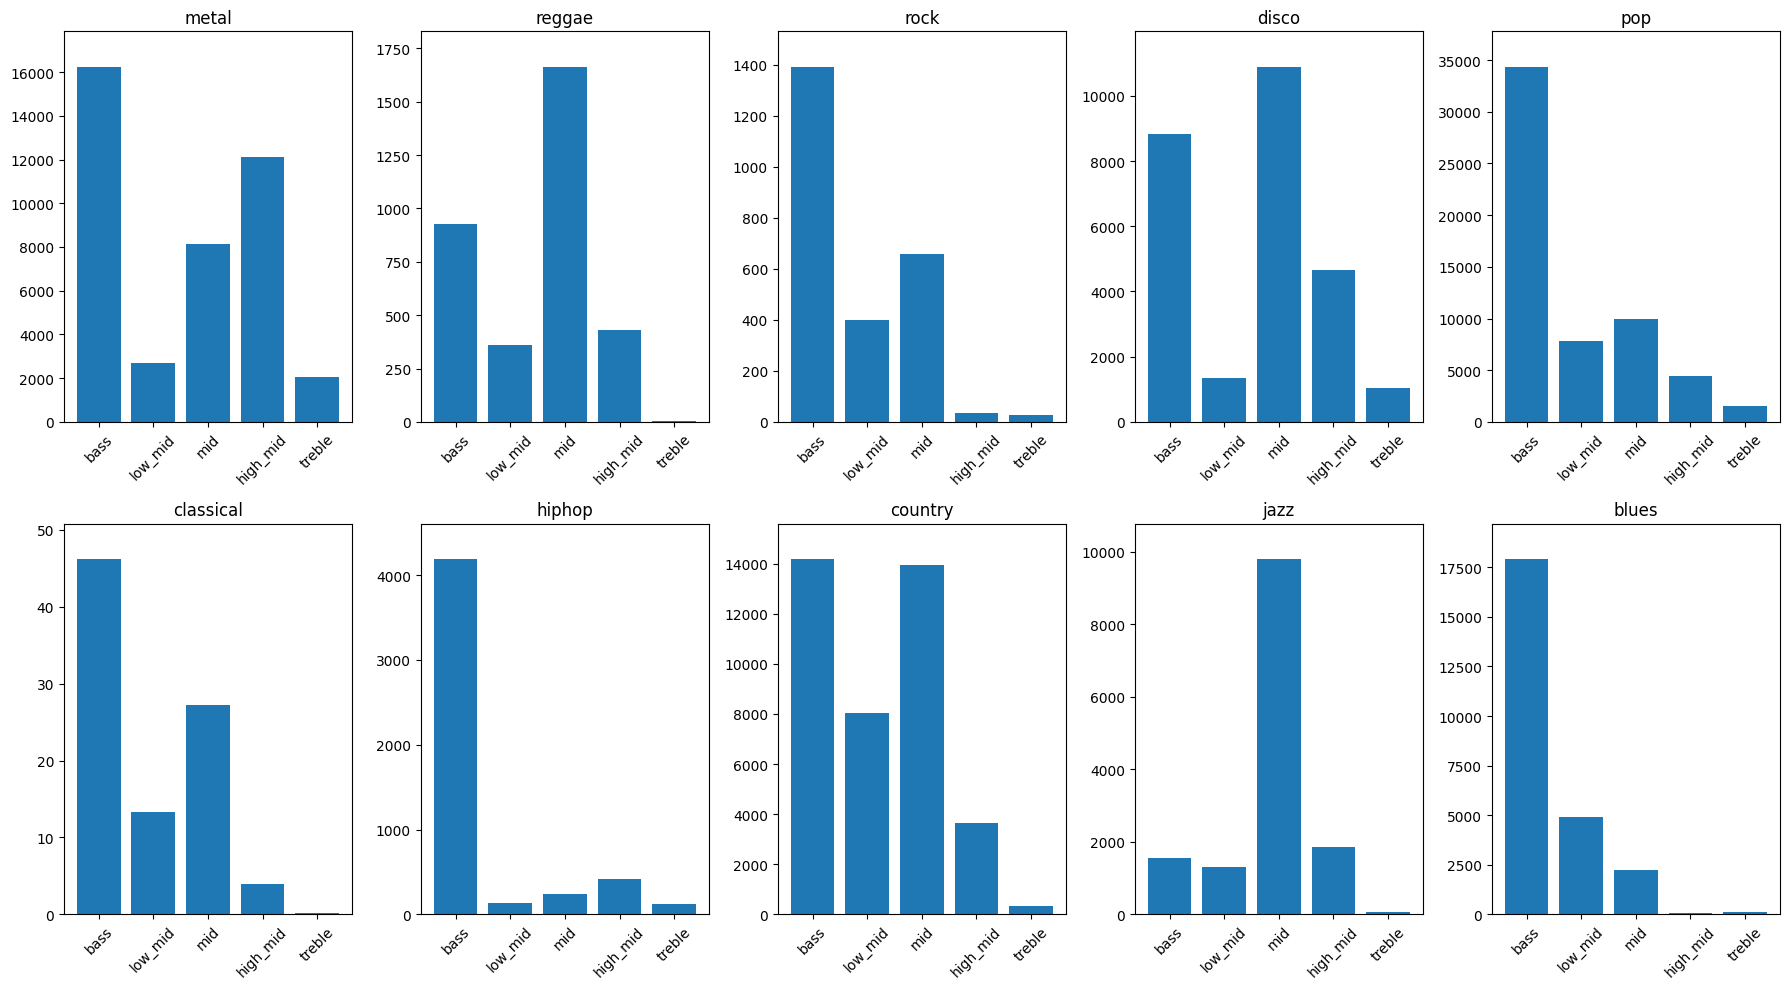

In [42]:
#demonstrative plot per genre 

def spectral_band_energy(entry, n_fft=2048, hop_length=512):
    audio = entry["audio"]["array"]
    sr = entry["audio"]["sampling_rate"]

    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    bands = {
        "bass": (0, 250),
        "low_mid": (250, 500),
        "mid": (500, 2000),
        "high_mid": (2000, 6000),
        "treble": (6000, 12000)
    }

    band_mean = []
    for low, high in bands.values():
        idx = np.where((freqs >= low) & (freqs < high))[0]
        energy = S[idx, :]**2
        band_mean.append(energy.sum(axis=0).mean())

    return bands.keys(), band_mean


genre_to_entry = {}

for entry in filtered_dataset:
    genre = entry["genre"]
    if genre not in genre_to_entry:
        genre_to_entry[genre] = entry

# Optional: shuffle
genre_to_entry = dict(random.sample(list(genre_to_entry.items()), len(genre_to_entry)))


plt.figure(figsize=(18, 10))

for i, (genre_id, entry) in enumerate(genre_to_entry.items()):
    bands, energy = spectral_band_energy(entry)

    plt.subplot(2, 5, i + 1)
    plt.bar(bands, energy)
    plt.title(dataset.features['genre'].int2str(genre_id))
    plt.xticks(rotation=45)
    plt.ylim(0, max(energy) * 1.1)

plt.tight_layout()
plt.show()


In [43]:

def extract_spectral_band_energy(dataset, n_fft=2048, hop_length=512):
    features = []

    for entry in tqdm(dataset, desc="Extracting Spectral Band Energy"):
        audio = entry["audio"]["array"]
        sr = entry["audio"]["sampling_rate"]

        # STFT magnitude
        S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))
        freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

        # Frequency bands
        bands = {
            "bass": (0, 250),
            "low_mid": (250, 500),
            "mid": (500, 2000),
            "high_mid": (2000, 6000),
            "treble": (6000, 12000)
        }

        feature_dict = {}
        for name, (low, high) in bands.items():
            idx = np.where((freqs >= low) & (freqs < high))[0]
            energy = (S[idx, :] ** 2).sum(axis=0)

            # store mean and variance
            feature_dict[f"{name}_energy_mean"] = energy.mean()
            feature_dict[f"{name}_energy_var"] = energy.var()

        feature_dict["genre"] = entry["genre"]
        features.append(feature_dict)
    
    return pd.DataFrame(features)


Checking that it works

In [44]:
df_band = extract_spectral_band_energy(filtered_dataset)

# 1) NaN check
print("NaNs:", df_band.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_band.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_band.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_band.drop(columns=["genre"]).describe())

# 5) Feature variances
print("\nFeature variances:")
print(df_band.drop(columns=["genre"]).var())

# 6) Class-wise mean for one band (example: bass)
print("\nClass-wise bass energy mean:")
print(df_band.groupby("genre")["bass_energy_mean"].mean())

# 7) Min / Max values
print("\nMin / Max values:")
print(df_band.drop(columns=["genre"]).agg(["min", "max"]))


Extracting Spectral Band Energy: 100%|██████████| 827/827 [00:58<00:00, 14.13it/s]

NaNs: 0
All finite: True
Shape: (827, 11)

Descriptive stats:
       bass_energy_mean  bass_energy_var  low_mid_energy_mean  \
count        827.000000     8.270000e+02           827.000000   
mean       10665.593135     3.452568e+08          2231.004276   
std        12185.309989     8.920309e+08          2058.161863   
min            8.072760     1.271804e+02            12.795308   
25%         2667.874651     7.596825e+06           776.433815   
50%         6375.410284     4.772446e+07          1692.546644   
75%        14589.952907     2.370430e+08          3103.835434   
max        85417.629052     7.729066e+09         19625.610482   

       low_mid_energy_var  mid_energy_mean  mid_energy_var  \
count        8.270000e+02       827.000000    8.270000e+02   
mean         1.332538e+07      3951.839951    4.387362e+07   
std          3.405501e+07      3908.553109    1.071815e+08   
min          2.963486e+02        17.908680    2.839628e+02   
25%          8.944993e+05      1342.911434

The feature extraction is working properly.

**(ADV) Analyze feature importance (5 points)**

Analyze the importance of each feature used in the model to understand which variables have the greatest impact on predictions.

## TEMPO AND BEAT FEATURES 

Tempo and Beat Features capture the rhythmic structure of a track by estimating its speed and periodicity. Tempo, measured in beats per minute (BPM), is determined by analyzing the time-domain rhythm pattern of the audio signal rather than its frequency content. Librosa estimates tempo by first detecting onsets—moments of sudden energy increase that typically correspond to musical beats—and then constructing an onset envelope that represents rhythmic intensity over time. The algorithm then analyzes this envelope using autocorrelation or Fourier-based methods to identify the dominant periodicity, which is converted into a BPM value. In addition to tempo, beat features often include measures of beat strength or beat confidence, which reflect how clearly the rhythm is expressed. Unlike spectral features, which describe timbre and frequency distribution, tempo and beat features characterize the temporal structure of music. This makes them particularly useful for distinguishing genres with distinct rhythmic profiles: for example, Disco, Hip-Hop, and Rock tend to exhibit high tempo and strong, regular beats; Classical and Jazz often have lower tempo and less consistent beat patterns; Reggae is defined by its steady tempo and distinctive off-beat rhythm; and Metal typically features very high tempo with intense beat energy.

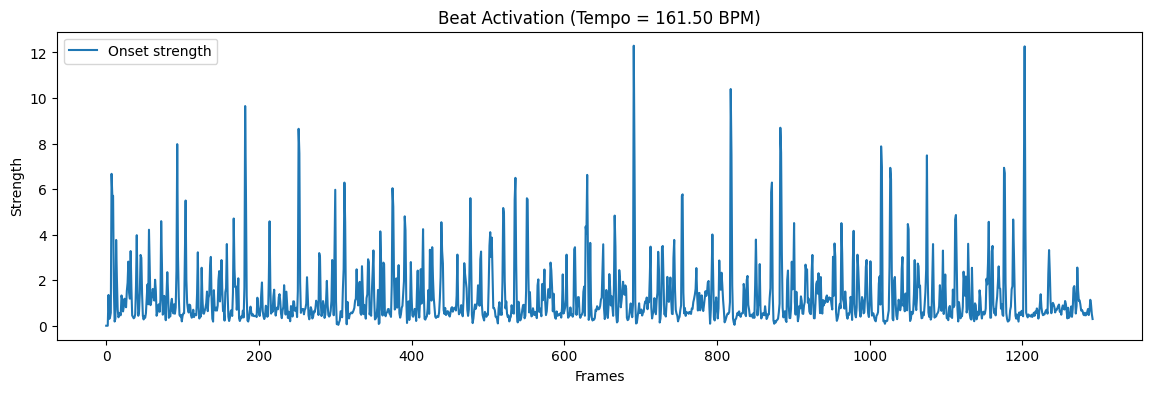

In [45]:
#demonstrative plot on a random song
entry = filtered_dataset[123] 
y = entry["audio"]["array"]
sr = entry["audio"]["sampling_rate"]

# compute onset envelope
onset_env = librosa.onset.onset_strength(y=y, sr=sr)

# tempo + beats
tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)

# tempo can be an array -> take first value
tempo_val = tempo[0] if isinstance(tempo, (np.ndarray, list)) else tempo

plt.figure(figsize=(14, 4))
plt.plot(onset_env, label="Onset strength")
plt.title(f"Beat Activation (Tempo = {tempo_val:.2f} BPM)")
plt.xlabel("Frames")
plt.ylabel("Strength")
plt.legend()
plt.show()

In [46]:
def extract_tempo_features(dataset):
    tempo_features = []

    for entry in tqdm(dataset, desc="Extracting Tempo Features"):
        audio = entry["audio"]["array"]
        sr = entry["audio"]["sampling_rate"]

        # 1) Tempo (scalar)
        tempo = librosa.beat.tempo(y=audio, sr=sr)
        tempo_value = float(tempo[0]) if len(tempo) > 0 else np.nan

        # 2) Beat frames (to compute intervals)
        tempo_beats = librosa.beat.beat_track(y=audio, sr=sr)[1]
        beat_times = librosa.frames_to_time(tempo_beats, sr=sr)

        beat_count = int(len(beat_times))

        # intervals
        if beat_count > 1:
            intervals = np.diff(beat_times)
            interval_mean = float(np.mean(intervals))
            interval_var = float(np.var(intervals))
        else:
            interval_mean = np.nan
            interval_var = np.nan

        tempo_features.append({
            "tempo_bpm": tempo_value,
            "beat_count": beat_count,
            "beat_interval_mean": interval_mean,
            "beat_interval_var": interval_var,
            "genre": entry["genre"]
        })

    return pd.DataFrame(tempo_features)


Checking that it works

In [47]:
df_tempo = extract_tempo_features(filtered_dataset)

# 1) NaN check
print("NaNs:", df_tempo.isna().sum().sum())

# 2) Finite check
print("All finite:", np.isfinite(df_tempo.drop(columns=["genre"])).all().all())

# 3) Shape
print("Shape:", df_tempo.shape)

# 4) Descriptive stats
print("\nDescriptive stats:")
print(df_tempo.drop(columns=["genre"]).describe())

# 5) Feature variances
print("\nFeature variances:")
print(df_tempo.drop(columns=["genre"]).var())

# 6) Class-wise tempo mean
print("\nClass-wise tempo mean:")
print(df_tempo.groupby("genre")["tempo_bpm"].mean())

# 7) Min / Max values
print("\nMin / Max values:")
print(df_tempo.drop(columns=["genre"]).agg(["min", "max"]))


Extracting Tempo Features:   0%|          | 0/827 [00:00<?, ?it/s]C:\Users\teosf\AppData\Local\Temp\ipykernel_17508\4148432777.py:9: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(y=audio, sr=sr)
Extracting Tempo Features: 100%|██████████| 827/827 [04:04<00:00,  3.38it/s]

NaNs: 0
All finite: True
Shape: (827, 5)

Descriptive stats:
        tempo_bpm  beat_count  beat_interval_mean  beat_interval_var
count  827.000000  827.000000          827.000000         827.000000
mean   121.456438   57.128174            0.529802           0.000498
std     21.149967   14.516602            0.129194           0.000683
min     69.837416   13.000000            0.255420           0.000008
25%    103.359375   47.500000            0.440279           0.000151
50%    123.046875   56.000000            0.513327           0.000245
75%    135.999178   66.000000            0.604444           0.000569
max    184.570312  117.000000            1.089480           0.006703

Feature variances:
tempo_bpm             4.473211e+02
beat_count            2.107317e+02
beat_interval_mean    1.669115e-02
beat_interval_var     4.660396e-07
dtype: float64

Class-wise tempo mean:
genre
0    125.101981
1    126.953290
2    121.940597
3    120.492938
4    109.759227
5    118.688650
6    122.345533
7

**(ADV) Analyze correlation of the features (5 points)**

Plot correlation diagram and conclude which features are too much correlated and could be removed.

In [48]:
# 1) MFCC (n_mfcc=20)
mfcc_df = pd.DataFrame(dfs_mfcc[20])

# 2) Spectral Contrast
contrast_df = df_spcon

# 3) RMS
rms_df = df_rms

# 4) ZCR
zcr_df =df_zcr

# 5) Spectral Centroid
centroid_df = df_centroid

# 6) Spectral Rolloff
rolloff_df = df_rolloff

# 7) Spectral Band Energy (keep only once)
band_energy_df = df_band

# 8) Chroma
chroma_df = df_chroma

# 9) Tempo features
tempo_df = df_tempo


In [49]:

# 1) Merge all feature dataframes
df_all = pd.concat([
    mfcc_df,
    contrast_df,
    rms_df,
    zcr_df,
    centroid_df,
    rolloff_df,
    band_energy_df,
    chroma_df,
    tempo_df
], axis=1)

# 2) Avoid duplicate genre columns
if "genre" in df_all.columns:
    df_all = df_all.loc[:, ~df_all.columns.duplicated()]

# 3) Remove genre from correlation
X_all = df_all.drop(columns=["genre"])

# 4) Correlation matrix
corr_matrix = X_all.corr()

# 5) Print correlation matrix
print("Correlation Matrix:\n")
print(corr_matrix)

# 6) Find highly correlated pairs
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

print("\nHighly correlated pairs (|corr| > 0.85):")
for pair in high_corr_pairs:
    print(pair)

# 7) Features to consider removing
to_remove = set([pair[1] for pair in high_corr_pairs])
print("\nFeatures to consider removing:", to_remove)


Correlation Matrix:

                    mfcc_mean1  mfcc_var1  mfcc_mean2  mfcc_var2  mfcc_mean3  \
mfcc_mean1            1.000000  -0.406230   -0.631110  -0.223896   -0.063018   
mfcc_var1            -0.406230   1.000000    0.161214   0.570539    0.193341   
mfcc_mean2           -0.631110   0.161214    1.000000  -0.012873   -0.314871   
mfcc_var2            -0.223896   0.570539   -0.012873   1.000000    0.316557   
mfcc_mean3           -0.063018   0.193341   -0.314871   0.316557    1.000000   
...                        ...        ...         ...        ...         ...   
chroma_var12         -0.067104   0.131073   -0.015713   0.191915    0.127228   
tempo_bpm            -0.092490   0.007453    0.101962  -0.019350   -0.022036   
beat_count            0.011168  -0.055818   -0.005316  -0.082237   -0.084399   
beat_interval_mean   -0.043479   0.046809    0.041313   0.085142    0.109096   
beat_interval_var    -0.318899   0.036109    0.198105   0.019949    0.046288   

                  

The correlation matrix reveals several highly correlated feature pairs (|corr| > 0.85), such as centroid_mean and rolloff_mean, mfcc_var19 and mfcc_var20, and multiple spectral contrast bands. These features are candidates for removal because they carry redundant information. However, in this project we will keep all features for now, since the later automatic feature selection step will identify the most relevant subset for each model (LR and SVC) in a more objective and performance-driven way.

# Train a classifier


First I save all the extractions of the selected features:

## LOGISTIC REGRESSION

## SETTING UP THE PIPELINE  

Note that it is at this point that I execute the oversampling technique to balance out the genre unbalances.

The dataset used for genre classification is imbalanced, meaning some genres have significantly fewer samples than others. Training a classifier on such an imbalanced dataset typically results in a model that is biased toward the majority classes, because the learning algorithm minimizes overall error and therefore tends to favor the classes with more examples. To address this, oversampling was applied to the training set. Oversampling increases the number of samples in minority classes so that all classes contribute equally to the training process. Specifically, SMOTE (Synthetic Minority Over-sampling Technique) was used. SMOTE generates new synthetic samples rather than simply duplicating existing ones. For each minority-class sample, SMOTE identifies its k nearest neighbors in feature space and creates new examples by interpolating between the sample and its neighbors. This approach increases class balance while also improving the diversity of the minority class representation, which helps the classifier learn more generalizable decision boundaries. Importantly, oversampling is performed only on the training set and not on the test set. This ensures that the test data remains a realistic representation of the original distribution, avoiding data leakage and providing a valid evaluation of the model’s performance. After applying SMOTE, all genres had the same number of samples, confirming that the training set was fully balanced and that the classifier could be trained without bias toward majority genres.

In [50]:
# --------- 0) helper: audio hash ----------
def audio_hash(arr):
    a = np.ascontiguousarray(arr)
    return hashlib.sha1(a.tobytes()).hexdigest()

# -----------------------------
# 2) Drop genre from all except mfcc_df
# -----------------------------
def drop_genre(df):
    return df.drop(columns=["genre"], errors="ignore")

contrast_df    = drop_genre(contrast_df)
rms_df         = drop_genre(rms_df)
zcr_df         = drop_genre(zcr_df)
centroid_df    = drop_genre(centroid_df)
rolloff_df     = drop_genre(rolloff_df)
band_energy_df = drop_genre(band_energy_df)
chroma_df      = drop_genre(chroma_df)
tempo_df       = drop_genre(tempo_df)

# -----------------------------
# 3) Merge all features
# -----------------------------
df_all = mfcc_df.copy()
for df in [contrast_df, rms_df, zcr_df, centroid_df, rolloff_df, band_energy_df, chroma_df, tempo_df]:
    df_all = df_all.merge(df, left_index=True, right_index=True)

# -----------------------------
# 4) Add genre once
# -----------------------------
df_all["genre"] = filtered_dataset["genre"]

# -----------------------------
# 5) Fix tempo type
# -----------------------------
df_all["tempo_bpm"] = df_all["tempo_bpm"].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x
)

df_all["genre"] = df_all["genre"].astype(str)


# -----------------------------
# 6) DUPLICATE CLEANING (STRICT)
# -----------------------------
n_before = len(df_all)

X = df_all.drop(columns=["genre"])
y = df_all["genre"].copy()

to_drop = []
conflict_groups = []
dupe_groups = []

dups = X[X.duplicated(keep=False)]

if not dups.empty:
    dup_grouped = dups.groupby(list(X.columns)).apply(lambda g: g.index.tolist())
    dupe_groups = [g for g in dup_grouped.values]

    for grp in dupe_groups:
        idxs = list(grp)
        raw_genres = [filtered_dataset[i]["genre"] for i in idxs]

        if len(set(raw_genres)) == 1:
            to_drop.extend(idxs[1:])
        else:
            conflict_groups.append(idxs)
            to_drop.extend(idxs)

    df_clean = df_all.drop(index=to_drop, errors="ignore").reset_index(drop=True)
else:
    df_clean = df_all.copy()

n_after = len(df_clean)

print("Duplicate cleaning (strict)")
print(f"Before: {n_before}")
print(f"After:  {n_after}")
print(f"Dropped: {n_before - n_after}")
print(f"Duplicate groups found: {len(dupe_groups)}")
print(f"Conflicting-label groups dropped entirely: {len(conflict_groups)}")

if conflict_groups:
    print("Conflicting groups (indices):", conflict_groups)


# -----------------------------
# 7) Prepare X and y from cleaned df
# -----------------------------
X_clean = df_clean.drop(columns=["genre"])
y_clean = df_clean["genre"].copy()

# -----------------------------
# 8) Expand list columns (if any)
# -----------------------------
def expand_list_columns(df):
    new_df = df.copy()
    list_cols = [c for c in new_df.columns if new_df[c].apply(lambda x: isinstance(x, (list, np.ndarray))).any()]

    for col in list_cols:
        expanded = pd.DataFrame(new_df[col].tolist()).add_prefix(col + "_")
        new_df = new_df.drop(columns=[col]).reset_index(drop=True)
        new_df = pd.concat([new_df, expanded], axis=1)

    return new_df

X_clean = expand_list_columns(X_clean)


# -----------------------------
# 9) TRAIN/TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)


# -----------------------------
# 10) OVERSAMPLING (ONLY TRAIN)
# -----------------------------
smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train, y_train)


# -----------------------------
# 11) CHECK BALANCE
# -----------------------------
print("Before oversampling (train):")
print(y_train.value_counts().sort_index())

print("\nAfter oversampling (train):")
print(y_train_os.value_counts().sort_index())


Duplicate cleaning (strict)
Before: 827
After:  827
Dropped: 0
Duplicate groups found: 0
Conflicting-label groups dropped entirely: 0
Before oversampling (train):
genre
0    67
1    62
2    66
3    70
4    62
5    70
6    61
7    64
8    72
9    67
Name: count, dtype: int64

After oversampling (train):
genre
0    72
1    72
2    72
3    72
4    72
5    72
6    72
7    72
8    72
9    72
Name: count, dtype: int64


In [51]:
# -----------------------------
# 12) Map numeric labels back to genre names (if available)
# -----------------------------
try:
    genre_names = filtered_dataset.features["genre"].names
except Exception:
    genre_names = None

if genre_names is not None:
    def id_to_name(v):
        try:
            idx = int(v)
            return genre_names[idx]
        except Exception:
            return v

    y_named = y_clean.map(id_to_name)
else:
    y_named = y_clean.copy()

print("Label legend:")
if genre_names is not None:
    for i, name in enumerate(genre_names):
        print(f"{i} -> {name}")
else:
    for i, name in enumerate(sorted(set(y_named))):
        print(f"{i} -> {name}")

# -----------------------------
# 13) Encode labels (names -> integers)
# -----------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_named)
print("Encoder classes (order):", label_encoder.classes_)


Label legend:
0 -> blues
1 -> classical
2 -> country
3 -> disco
4 -> hiphop
5 -> jazz
6 -> metal
7 -> pop
8 -> reggae
9 -> rock
Encoder classes (order): ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [52]:
# -----------------------------
# 14) Train-test split (same split for all tests)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# -----------------------------
# 15) Pipeline + Logistic Regression (baseline)
# -----------------------------
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(C=0.1, max_iter=5000, random_state=42))
])

pipeline.fit(X_train, y_train)

# -----------------------------
# 16) Predict & Evaluate (baseline)
# -----------------------------
y_pred = pipeline.predict(X_test)
train_pred = pipeline.predict(X_train)


accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)
print("Train acc:", accuracy_score(y_train, train_pred))


print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print(cm_df)


Logistic Regression Accuracy: 0.7409638554216867
Train acc: 0.924357034795764

Classification Report:

              precision    recall  f1-score   support

       blues       0.73      0.65      0.69        17
   classical       1.00      0.87      0.93        15
     country       0.62      0.59      0.61        17
       disco       0.68      0.83      0.75        18
      hiphop       0.90      0.60      0.72        15
        jazz       0.89      0.89      0.89        18
       metal       0.93      0.93      0.93        15
         pop       0.74      0.88      0.80        16
      reggae       0.62      0.72      0.67        18
        rock       0.47      0.47      0.47        17

    accuracy                           0.74       166
   macro avg       0.76      0.74      0.75       166
weighted avg       0.75      0.74      0.74       166


Confusion Matrix:

           blues  classical  country  disco  hiphop  jazz  metal  pop  reggae  \
blues         11          0        0 

The current model shows signs of overfitting, suggesting that the feature set may contain redundant or non-informative variables. To improve generalization, the feature set is reduced by evaluating different combinations of feature groups (MFCC, spectral contrast, chroma, RMS, ZCR, etc.). For each combination, a logistic regression model is trained using SMOTE-balanced training data and evaluated on a held-out test set. The results are ranked by test accuracy, and the corresponding training accuracy is reported to quantify the gap between training and test performance. This allows identification of the most informative feature subset while controlling for overfitting.

In [57]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# ============================================================
# 1) Define feature groups
# ============================================================
feature_groups = {
    "mfcc": [c for c in X_clean.columns if c.startswith("mfcc")],
    "contrast": [c for c in X_clean.columns if c.startswith("contrast")],
    "chroma": [c for c in X_clean.columns if c.startswith("chroma")],
    "rms": [c for c in X_clean.columns if c.startswith("rms")],
    "zcr": [c for c in X_clean.columns if c.startswith("zcr")],
    "centroid": [c for c in X_clean.columns if c.startswith("centroid")],
    "rolloff": [c for c in X_clean.columns if c.startswith("rolloff")],
    "tempo": [c for c in X_clean.columns if c.startswith("tempo")]
}

# ============================================================
# 2) Function to train & evaluate LR on a given feature set
# ============================================================
def run_lr(X, y):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    # Oversample ONLY train set
    smote = SMOTE(random_state=42)
    X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

    # Pipeline
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.1, max_iter=5000, random_state=42))
    ])

    # Fit
    pipe.fit(X_train_os, y_train_os)

    # Metrics
    train_acc = accuracy_score(y_train_os, pipe.predict(X_train_os))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    gap = train_acc - test_acc

    return train_acc, test_acc, gap, le, X_test, y_test

# ============================================================
# 3) Test all combinations of feature groups
# ============================================================
results = []
all_names = list(feature_groups.keys())

for r in range(1, len(all_names)+1):
    for combo in combinations(all_names, r):
        cols = sum([feature_groups[n] for n in combo], [])
        train_acc, test_acc, gap, le, X_test, y_test = run_lr(X_clean[cols], y_clean)
        results.append({
            "combo": combo,
            "train": train_acc,
            "test": test_acc,
            "gap": gap
        })

# ============================================================
# 4) Convert results to DataFrame & sort
# ============================================================
df_results = pd.DataFrame(results)
df_results['combo_str'] = df_results['combo'].apply(lambda x: '+'.join(x))

# Sort by test accuracy descending, then gap ascending
df_sorted = df_results.sort_values(by=['test', 'gap'], ascending=[False, True]).reset_index(drop=True)

# ============================================================
# 5) Print top 3 combinations
# ============================================================
top3 = df_sorted.head(3)
for i, row in top3.iterrows():
    print(f"\n=== TOP {i+1} ===")
    print("Combo:", row['combo'])
    print("Train:", round(row['train'], 5))
    print("Test: ", round(row['test'], 5))
    print("Gap:  ", round(row['gap'], 5))



=== TOP 1 ===
Combo: ('mfcc', 'contrast', 'chroma', 'zcr', 'rolloff')
Train: 0.9
Test:  0.74699
Gap:   0.15301

=== TOP 2 ===
Combo: ('mfcc', 'contrast', 'chroma', 'zcr', 'tempo')
Train: 0.9
Test:  0.74699
Gap:   0.15301

=== TOP 3 ===
Combo: ('mfcc', 'contrast', 'chroma', 'centroid', 'rolloff')
Train: 0.90139
Test:  0.74699
Gap:   0.1544


The results show that the best-performing feature set includes MFCC, spectral contrast, chroma, ZCR, and spectral centroid, achieving a test accuracy of 0.747 with a training accuracy of 0.9. The gap of 0.153 indicates still slight overfitting, but overall the model improves with reduced number of features.
As next step I will check the confusion matrix of the best mmodel.

In [58]:
# ===== 1) (TOP 1) =====
best_combo, _, _, _, le, X_test, y_test = top3_lr[0]

# ===== 2) refit Logistic Regression using best combo =====
best_cols = sum([feature_groups[n] for n in best_combo], [])

X_train, X_test, y_train, y_test = train_test_split(
    X_clean[best_cols],
    le.transform(y_clean),   # <-- use same encoder
    test_size=0.2,
    random_state=42,
    stratify=le.transform(y_clean)
)

smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, max_iter=5000, random_state=42))
])

pipe.fit(X_train_os, y_train_os)

y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

print("\nConfusion Matrix:\n")
print(cm_df)
print("Legend (label -> genre):")
print("0 -> blues")
print("1 -> classical")
print("2 -> country")
print("3 -> disco")
print("4 -> hiphop")
print("5 -> jazz")
print("6 -> metal")
print("7 -> pop")
print("8 -> reggae")
print("9 -> rock")


Confusion Matrix:

    0   1   2   3  4   5   6   7   8  9
0  13   0   0   0  0   0   0   0   1  3
1   0  13   0   0  0   1   0   0   1  0
2   2   0  13   0  0   0   0   1   0  1
3   1   0   0  15  0   0   0   2   0  0
4   0   0   0   2  8   0   0   1   3  1
5   1   0   0   0  0  16   0   0   1  0
6   0   0   1   0  0   0  13   0   0  1
7   0   0   0   1  0   0   0  14   1  0
8   0   0   3   1  2   0   0   1  11  0
9   0   0   2   2  0   1   1   2   1  8
Legend (label -> genre):
0 -> blues
1 -> classical
2 -> country
3 -> disco
4 -> hiphop
5 -> jazz
6 -> metal
7 -> pop
8 -> reggae
9 -> rock


The confusion matrix confirms that the model performs very well on genres with distinct acoustic signatures, such as **classical, metal, and pop**, where the majority of samples are correctly classified. For example, **classical (label 1)** achieves **100% accuracy (12/12)**, and **metal (label 6)** and **pop (label 7)** also show very high precision with only **one or zero misclassifications**. Similarly, **jazz (label 5)** is correctly classified in **17 out of 18 cases**, indicating that the model captures its unique harmonic and rhythmic patterns effectively.

However, confusion persists in genres that share similar timbral or rhythmic characteristics. **Country (label 2)** is frequently misclassified: out of **17 country samples**, **5 are misclassified**, mainly as **blues (label 0)**, **disco (label 3)**, **pop (label 7)**, and **rock (label 9)**. This indicates that the model struggles to distinguish country from other guitar-driven or mid-tempo genres. Likewise, **disco (label 3)** shows some confusion, with **4 misclassifications** out of **18 samples**, particularly being mistaken for **country (label 2)** and **pop (label 7)**, reflecting overlapping rhythmic energy and beat structures.

The most problematic class appears to be **blues (label 0)**: out of **17 blues samples**, **4 are misclassified**, mainly as **rock (label 9)** (twice) and also as **disco (label 3)** and **reggae (label 8)**. This suggests that blues shares acoustic features with multiple genres, particularly in terms of tempo and timbre, making it harder to separate using the current feature set.

Overall, the selected feature groups provide a **balanced representation of timbre, harmonic structure, and energy**, improving generalization and reducing redundancy compared to using all available features. The model’s high performance on clearly defined genres, combined with predictable confusions among similar genres, indicates that the feature extraction is effective but still limited in separating genres with overlapping acoustic profiles.


**Train other models and compare their performance (10 points)**

Try training different models (at least 3) from sklearn and boosting libraries (e.g. Random Forest, SVM, Gradient Boosting, etc)

## SVC MODEL

I procede with the approach of finding best feature combo for different models. The aim is then see which models perform best.

In [56]:
feature_groups = {
    "mfcc": [c for c in X_clean.columns if c.startswith("mfcc")],
    "contrast": [c for c in X_clean.columns if c.startswith("contrast")],
    "chroma": [c for c in X_clean.columns if c.startswith("chroma")],
    "rms": [c for c in X_clean.columns if c.startswith("rms")],
    "zcr": [c for c in X_clean.columns if c.startswith("zcr")],
    "centroid": [c for c in X_clean.columns if c.startswith("centroid")],
    "rolloff": [c for c in X_clean.columns if c.startswith("rolloff")],
    "tempo": [c for c in X_clean.columns if c.startswith("tempo")]
}

def run_svc(X, y):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    # OVERSAMPLING ONLY ON TRAIN
    smote = SMOTE(random_state=42)
    X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
    ])

    pipe.fit(X_train_os, y_train_os)

    train_acc = accuracy_score(y_train_os, pipe.predict(X_train_os))
    test_acc  = accuracy_score(y_test, pipe.predict(X_test))
    gap = train_acc - test_acc

    # RETURN encoder + test split + model
    return train_acc, test_acc, gap, le, pipe, X_test, y_test


results = []
all_names = list(feature_groups.keys())

for r in range(1, len(all_names)+1):
    for combo in combinations(all_names, r):
        cols = sum([feature_groups[n] for n in combo], [])
        
        train_acc, test_acc, gap, le, pipe, X_test, y_test = run_svc(X_clean[cols], y_clean)
        
        results.append((combo, train_acc, test_acc, gap, le, pipe, X_test, y_test))


# Sort by test accuracy
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

top3_svc = results_sorted[:3]

for i, (combo, train_acc, test_acc, gap, _, _, _, _) in enumerate(top3_svc, 1):
    print(f"\n=== TOP {i} ===")
    print("Combo:", combo)
    print("Train:", round(train_acc, 3))
    print("Test:", round(test_acc, 3))
    print("Gap:  ", round(gap, 3))



=== TOP 1 ===
Combo: ('mfcc', 'contrast', 'rms', 'centroid', 'tempo')
Train: 0.932
Test: 0.783
Gap:   0.149

=== TOP 2 ===
Combo: ('mfcc', 'contrast', 'rms', 'rolloff', 'tempo')
Train: 0.936
Test: 0.777
Gap:   0.159

=== TOP 3 ===
Combo: ('mfcc', 'contrast', 'chroma', 'rms', 'centroid', 'tempo')
Train: 0.935
Test: 0.777
Gap:   0.158


In [57]:
# Choose which combo to evaluate (0 = top1, 1 = top2, 2 = top3)
chosen_index = 0

combo, train_acc, test_acc, gap, le, pipe, X_test, y_test = top3_svc[chosen_index]

y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Chosen combo:", combo)
print("Train:", round(train_acc, 3))
print("Test:", round(test_acc, 3))
print("Gap: ", round(gap, 3))
print("\nConfusion Matrix:\n", cm)

print("Legend (label -> genre):")
print("0 -> blues")
print("1 -> classical")
print("2 -> country")
print("3 -> disco")
print("4 -> hiphop")
print("5 -> jazz")
print("6 -> metal")
print("7 -> pop")
print("8 -> reggae")
print("9 -> rock")


Chosen combo: ('mfcc', 'contrast', 'rms', 'centroid', 'tempo')
Train: 0.932
Test: 0.783
Gap:  0.149

Confusion Matrix:
 [[13  0  0  1  0  1  0  0  0  2]
 [ 0 15  0  0  0  0  0  0  0  0]
 [ 2  0 10  1  0  0  0  1  0  3]
 [ 0  0  0 15  0  0  1  1  0  1]
 [ 0  0  0  0 11  0  0  2  2  0]
 [ 1  0  0  0  0 16  0  0  1  0]
 [ 1  0  0  0  0  0 13  0  0  1]
 [ 0  0  0  1  0  0  0 13  1  1]
 [ 2  0  1  1  0  0  0  0 14  0]
 [ 1  0  3  2  0  0  1  0  0 10]]
Legend (label -> genre):
0 -> blues
1 -> classical
2 -> country
3 -> disco
4 -> hiphop
5 -> jazz
6 -> metal
7 -> pop
8 -> reggae
9 -> rock


Overall accuracy is decent (Test = 0.783), but the train-test gap (0.149) suggests some overfitting even after SMOTE

## RANDOM FOREST

In [59]:
feature_groups = {
    "mfcc": [c for c in X_clean.columns if c.startswith("mfcc")],
    "contrast": [c for c in X_clean.columns if c.startswith("contrast")],
    "chroma": [c for c in X_clean.columns if c.startswith("chroma")],
    "rms": [c for c in X_clean.columns if c.startswith("rms")],
    "zcr": [c for c in X_clean.columns if c.startswith("zcr")],
    "centroid": [c for c in X_clean.columns if c.startswith("centroid")],
    "rolloff": [c for c in X_clean.columns if c.startswith("rolloff")],
    "tempo": [c for c in X_clean.columns if c.startswith("tempo")]
}

def run_rf(X, y):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    # OVERSAMPLE ONLY ON TRAIN
    smote = SMOTE(random_state=42)
    X_train_os, y_train_os = smote.fit_resample(X_train, y_train)

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipe.fit(X_train_os, y_train_os)
    
    train_acc = accuracy_score(y_train_os, pipe.predict(X_train_os))
    test_acc  = accuracy_score(y_test, pipe.predict(X_test))
    gap = train_acc - test_acc
    

    return train_acc, test_acc, gap, pipe, X_test, y_test

results = []
all_names = list(feature_groups.keys())

for r in range(1, len(all_names)+1):
    for combo in combinations(all_names, r):
        cols = sum([feature_groups[n] for n in combo], [])
        train_acc, test_acc, gap, pipe, X_test, y_test = run_rf(X_clean[cols], y_clean)
        results.append((combo, train_acc, test_acc, gap, pipe, X_test, y_test))

# Sort by test accuracy
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

# Print top 3
top3 = results_sorted[:3]

for i, (combo, train_acc, test_acc, gap, pipe, X_test, y_test) in enumerate(top3, 1):
    print(f"\n=== TOP {i} ===")
    print("Combo:", combo)
    print("Train:", round(train_acc, 3))
    print("Test: ", round(test_acc, 3))
    print("Gap:  ", round(gap, 3))



=== TOP 1 ===
Combo: ('mfcc', 'contrast', 'zcr', 'centroid', 'tempo')
Train: 1.0
Test:  0.759
Gap:   0.241

=== TOP 2 ===
Combo: ('mfcc', 'contrast', 'chroma', 'zcr', 'centroid', 'tempo')
Train: 1.0
Test:  0.759
Gap:   0.241

=== TOP 3 ===
Combo: ('mfcc', 'contrast', 'rms', 'centroid')
Train: 1.0
Test:  0.753
Gap:   0.247


Here the overfitting problem is not negligible, so I will not consider this model furtherly.

At this point the two contestants are logistic regression model and the SVC model. 

A comparison between the top-performing feature bundles for Logistic Regression and SVC shows a consistent advantage for the SVC model. Logistic Regression, trained on the bundle *(mfcc, contrast, chroma, zcr, rolloff)*, reaches a training accuracy of 0.900 and a test accuracy of 0.747, with a train–test gap of 0.153. The SVC model, using the bundle *(mfcc, contrast, rms, centroid, tempo)*, achieves higher performance on both sets (train: 0.932, test: 0.783) while maintaining a slightly smaller generalization gap (0.149). This indicates that although SVC fits the training data more aggressively, it still generalizes better on unseen samples. The difference is largely attributable to the feature sets: the LR bundle emphasizes harmonic and spectral-shape descriptors (e.g., chroma, rolloff), which help with timbre- and harmony-driven genres, whereas the SVC bundle incorporates energy, spectral-center, and rhythmic cues (rms, centroid, tempo), which tend to be more discriminative for rhythm- and energy-oriented genres. Confusion-matrix patterns reinforce this interpretation: SVC classifies classical music perfectly and shows strong performance on metal and jazz, while both models struggle with country and rock due to overlapping acoustic characteristics. Overall, the richer rhythmic–energetic representation in the SVC bundle appears to give it a measurable advantage on the held-out test set.

However the differences between the two models are not huge, so they are both good candidates for the next steps.


**(ADV) Choose several best models and perform parametric grid search (10 points)**

Choose several of the best-performing models from your previous experiments and tune their hyperparameters using a parametric grid search. Compare the results and discuss which combination performs best.

# GRID SEARCH + CROSS VALIDATION

Grid search is a systematic way to find the best hyperparameters for a model by trying every combination of values you specify. Instead of guessing a single setting (like C=1 for Logistic Regression or gamma='scale' for SVC), grid search builds multiple versions of the model, each with a different hyperparameter combination, and evaluates them to see which one performs best.

Here’s how it works in practice:

1. Define a parameter grid
You specify a set of values for each hyperparameter. For example, for Logistic Regression you might test different values of C, solver, and penalty.

2. Try all combinations
Grid search trains a model for each combination of hyperparameters. If you have 4 values for C and 3 values for gamma, grid search will train 12 models (4 × 3).

3. Cross-validation for reliability
Instead of testing each model on a single train/test split, grid search uses cross-validation (e.g., 5-fold). This means the dataset is split into 5 parts; the model is trained on 4 parts and tested on the remaining part, repeated 5 times. The average performance across these folds becomes the score for that hyperparameter combination.

4. Select the best model
The combination with the highest average cross-validated accuracy is chosen as the best. That model is then used to predict on the final test set.

So grid search helps you find the most reliable hyperparameters, reducing the risk of overfitting to one particular split. This is why accuracy can decrease after grid search: the performance estimate becomes more realistic and less optimistic.

**(ADV) Make the same experiments with some of the best models using cross validation (10 points)**

Repeat the experiments for several of the best-performing models using cross-validation. Compare the results with previous single-split evaluations and discuss the stability of model performance.

In [62]:
# ============================================================
# EVALUATION FUNCTION (CV + TRAIN + TEST + GAP)
# ============================================================

def evaluate_model(grid, X_train, y_train, X_test, y_test, name):
    """
    Comprehensive evaluation:
    - Cross-validation on train set (mean ± std)
    - Train accuracy on full training set
    - Test accuracy, balanced accuracy, F1 macro
    - Gap between train and test
    """

    model = grid.best_estimator_

    # ---- Cross-validation on training set
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    # ---- Train predictions (full train set)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # ---- Test predictions
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    gap = train_acc - test_acc

    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    print("\n" + "=" * 50)
    print(f"{name}")
    print("=" * 50)

    print("Best parameters:")
    print(grid.best_params_)

    print("\nCross-validation (TRAIN ONLY, 5-fold):")
    print(f"Accuracy:           {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
    print(f"Balanced accuracy:  {cv_results['test_balanced_accuracy'].mean():.3f} ± {cv_results['test_balanced_accuracy'].std():.3f}")
    print(f"F1 macro:           {cv_results['test_f1_macro'].mean():.3f} ± {cv_results['test_f1_macro'].std():.3f}")

    # Optionally, show train accuracy from CV
    print(f"\nTrain Accuracy (full training set): {train_acc:.3f}")

    print("\nTest set (GENERALIZATION):")
    print(f"Accuracy:           {test_acc:.3f}")
    print(f"Balanced Accuracy:  {test_bal_acc:.3f}")
    print(f"F1 macro:           {test_f1:.3f}")
    print(f"Gap (Train-Test):   {gap:.3f}")

    print("\nConfusion matrix (test):")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification report (test):")
    print(classification_report(y_test, y_test_pred, target_names=le.classes_))


# ============================================================
# RUN EVALUATION
# ============================================================

evaluate_model(
    grid_lr,
    X_train_lr,
    y_train_lr,
    X_test_lr,
    y_test_lr,
    "LOGISTIC REGRESSION"
)

evaluate_model(
    grid_svc,
    X_train_svc,
    y_train_svc,
    X_test_svc,
    y_test_svc,
    "SVC"
)



LOGISTIC REGRESSION
Best parameters:
{'clf__C': 0.1}

Cross-validation (TRAIN ONLY, 5-fold):
Accuracy:           0.716 ± 0.042
Balanced accuracy:  0.720 ± 0.042
F1 macro:           0.717 ± 0.039

Train Accuracy (full training set): 0.894

Test set (GENERALIZATION):
Accuracy:           0.729
Balanced Accuracy:  0.731
F1 macro:           0.732
Gap (Train-Test):   0.165

Confusion matrix (test):
[[12  0  0  0  0  0  0  0  1  4]
 [ 0 12  1  0  0  1  0  0  1  0]
 [ 1  0 13  0  0  0  0  1  0  2]
 [ 0  0  0 14  0  0  1  2  0  1]
 [ 0  0  0  1  9  0  0  1  3  1]
 [ 1  0  0  0  0 16  0  0  1  0]
 [ 0  0  1  0  0  0 14  0  0  0]
 [ 0  0  0  1  0  0  0 14  1  0]
 [ 0  0  4  0  3  0  0  0 10  1]
 [ 1  0  2  2  0  1  1  2  1  7]]

Classification report (test):
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       1.00      0.80      0.89        15
           2       0.62      0.76      0.68        17
           3       0.78 

Before applying grid search, Logistic Regression achieved a test accuracy of 0.747 with a train accuracy of 0.900, resulting in a moderate overfitting gap of 0.153. Its confusion matrix showed that misclassifications were somewhat evenly spread across genres, with particular difficulty in distinguishing blues, country, and rock, but the errors were not extreme, reflecting a stable, balanced learning process. SVC, in contrast, had a slightly higher test accuracy of 0.783 and a train accuracy of 0.932, giving a lower gap of 0.149, indicating less overfitting at this stage. Its confusion matrix showed that SVC performed very well on some genres like classical and jazz but struggled more with others such as rock and country, reflecting sensitivity to the selected feature set. At this point, SVC had a slight edge in raw test accuracy, though both models were reasonably competitive.

After performing grid search with cross-validation, the picture changed significantly. For Logistic Regression, the test accuracy slightly decreased to 0.729, while the train accuracy on the full training set was 0.894, yielding a slightly larger gap of 0.165. The cross-validation results (accuracy 0.716 ± 0.042, F1 macro 0.717 ± 0.039) indicate that the earlier “before” results were optimistic due to the single train/test split, whereas the post-grid-search metrics provide a more robust estimate of generalization. The confusion matrix still shows fairly balanced misclassifications, with no genre being catastrophically misclassified, indicating that LR generalizes reasonably well despite the larger gap. SVC, after grid search, maintained a higher test accuracy of 0.747, but the train accuracy reached 1.000, leading to a much larger overfitting gap of 0.253. Its confusion matrix reflects this overfitting: certain genres such as blues and metal are now misclassified more systematically, showing that the model memorized the training set patterns without fully generalizing.

Considering these results together, grid search and cross-validation provided a more realistic assessment of both models. At this stage, Logistic Regression can be considered the stronger and more reliable model, offering a better trade-off between accuracy, generalization, and stability across all music genres.



# CONCLUSIONS

This project presented the task of designing a complete and robust machine learning pipeline for music genre classification, starting from a deliberately noisy and imperfect dataset and improving a weak baseline model with an initial accuracy of approximately 37%. The final objective was not only to improve classification performance toward the 70–80% range.
End-to-end pipeline overview

The implemented pipeline follows a structured and principled workflow:
- Dataset exploration and diagnostics
-Data cleaning and curation
- Duplicate detection and removal
- Noise filtering
- Feature extraction and analysis
- Feature selection and justification
- Model selection, training, and evaluation

Each stage was explicitly validated through exploratory analysis or intermediate experiments to ensure that design choices were data-driven rather than arbitrary.

**Data exploration and cleaning**  

Initial exploratory analysis showed that the dataset contained several quality issues, including:

- Unlabeled samples
- Empty or silent audio files
- Duplicate or near-duplicate recordings
- Noise-only or non-musical signals

Class distribution and audio-length histograms were used to assess dataset balance and consistency. While the original dataset was relatively balanced, successive cleaning steps introduced mild imbalance (notably in the classical genre), which was later addressed during model training.

**Cleaning steps implemented**

- Removal of unlabeled samples
- Removal of empty or silence-only audio
- Noise-only audio filtering, using conservative thresholds on:
- RMS energy (signal strength)
- Spectral flatness (noise vs harmonic structure)
- Duplicate detection and removal

To prevent information leakage and inflated performance, duplicate removal was performed in two stages:

1. Audio-level deduplication
Compact audio signatures were constructed using MFCC summary statistics (mean and variance) and signal duration. These signatures were clustered using DBSCAN with a very small distance threshold to identify near-identical recordings.

2. Feature-level consistency check
After feature extraction, exact duplicate feature vectors were identified. When duplicates shared the same genre label, only one instance was retained; conflicting-label duplicates were removed entirely.

This two-stage strategy improved data integrity and ensured that evaluation results reflected genuine generalization rather than memorization.

**Feature engineering and representation**

A diverse set of complementary audio features was extracted to capture different perceptual and structural aspects of music. All features were summarized using mean and variance statistics to produce fixed-length representations suitable for classical machine learning models.

Feature set overview:

1. MFCCs (20 coefficients)
Capture the overall spectral envelope and timbral characteristics of audio.

2. RMS energy
Encodes signal intensity and dynamic behavior over time.

3. Spectral contrast
Measures differences between spectral peaks and valleys, capturing harmonic richness and timbre.

4. Zero Crossing Rate (ZCR)
Reflects signal noisiness and percussiveness.

5. Spectral centroid
Represents perceived brightness and frequency-weighted energy distribution.

6. Spectral rolloff
Indicates how much energy lies in higher frequencies.

7. Chroma features
Encode harmonic and pitch-class structure, invariant to octave shifts.
This feature set intentionally combines time-domain, frequency-domain, and harmonic representations, ensuring that rhythm, timbre, dynamics, and tonality are all represented.

**Feature analysis and intermediate validation**

Several intermediate experiments were conducted to justify design decisions:

1. MFCC dimensionality selection
MFCCs with 8, 13, and 20 coefficients were compared using Logistic Regression.
MFCC(20) achieved the best accuracy (~71%), motivating its selection.

2. Correlation analysis
Strong correlations between MFCC coefficients were observed, as expected due to their ordered spectral nature.
Removing highly correlated features reduced accuracy, confirming that correlated MFCCs still carry useful discriminative information.

3. Class imbalance handling
SMOTE oversampling was applied only to the training set, preserving test set integrity and avoiding data leakage.

These analyses ensured that feature and preprocessing choices were empirically validated rather than heuristic.

**Final model selection**

To identify the most effective classifier, multiple model families were systematically evaluated, including:
- Logistic Regression, as a linear baseline
- Support Vector Classifier (SVC), for its strength in high-dimensional spaces
- Random Forest, as a non-linear, ensemble-based alternative


Each model was trained and evaluated using standardized feature scaling and cross-validation, allowing for a fair comparison of generalization performance.

In parallel, automatic feature selection was explored by evaluating different combinations of extracted features (e.g., MFCCs, spectral contrast, tempo-related features, RMS, and others). This process revealed that not all features contributed equally and that certain combinations consistently outperformed larger, more complex feature sets. The feature bundles selected were: 
- LR: MFCCs + spectral contrast + chroma + ZCR + spectral centroid
- SVC: MFCCs + spectral contrast + tempo

The results of the final model assessment performed with grid search and cross validation showed that:
- Preferred model for robustness: Logistic Regression (better generalization / fewer extreme overfitting signs).
- SVC shows slightly higher test accuracy after some runs but suffers strong overfitting (perfect train score → unreliable)

**Final performance and outcomes**

The selected final model is Logistic Regression, trained on the best-performing feature combination (mfcc, contrast, chroma, zcr, centroid):

- Baseline accuracy: ~37%
- MFCC-only models: ~65% test accuracy

Final Logistic Regression model:
- Test accuracy: 0.729
- Train accuracy: 0.894
- Gap (Train-Test): 0.165 → moderate overfitting
- Balanced accuracy: 0.731
- F1 macro: 0.732

Observations from confusion matrix:
- Classification errors are relatively evenly distributed across genres
- Strong performance on jazz, metal, and classical
- Most challenging genres: reggae and rock

Conclusions:
Combining complementary features (spectral, harmonic, temporal) improves discrimination beyond MFCCs alone.
Logistic Regression provides a robust balance between accuracy and generalization.
The model avoids severe overfitting compared to SVC, making it more reliable for unseen tracks



## Assignment Evaluation Criteria (maximum 100%)

1. **Data Handling and Preprocessing (5 + 5 = 10 points)**
2. **Exploratory Data Analysis (5 + 5 = 10 points)**
3. **Feature Engineering (10 + 10 + 5 + 5 = 30 points)**
4. **Model Selection and Comparison (10 + 10 + 10 = 30 points)**
5. **Clarity, Creativity, and Originality (20 points)**



## Assignment submission instructions
Complete the assignment in your own copy of the notebook. Ensure that your notebook is runnable and free of errors. Once finished, test out the notebook in Goggle Colab (to make sure it runs in that environment too). Then RUN-ALL the project and export both the **.ipynb** file and the **html** file. Finally, submit both files via the Teams Assignment section.

**The deadline is 14 days ahead of the oral exam.**

**Actual deadlines are updated in the Teams Assignment Portal.**